In [1]:
pip install setuptools --upgrade

Defaulting to user installation because normal site-packages is not writeable
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\jiang\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
!pip install neuralforecast xgboost fredapi yfinance statsmodels scikit-learn scipy matplotlib pandas numpy setuptools -q


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\jiang\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
 
import yfinance as yf
from fredapi import Fred
import os
 
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from xgboost import XGBRegressor

2026-03-14 17:31:34,577	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-14 17:31:38,986	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# =============================================================================
# STEP 1 — Download market & macro data
# =============================================================================
print("=" * 65)
print("STEP 1 — Downloading market & macro data")
print("=" * 65)
 
START, END = "2000-01-01", "2025-01-01"
 
# ── QQQ ──────────────────────────────────────────────────────────────────────
print("  Downloading QQQ...")
qqq_raw = yf.download("QQQ", start=START, end=END, interval="1d", auto_adjust=True)
qqq_raw.columns = qqq_raw.columns.get_level_values(0)
qqq = qqq_raw[["Close"]].rename(columns={"Close": "QQQ"})
qqq.index = pd.to_datetime(qqq.index).tz_localize(None)
 
# ── VIX ──────────────────────────────────────────────────────────────────────
print("  Downloading VIX...")
vix_raw = yf.download("^VIX", start=START, end=END, interval="1d", auto_adjust=True)
vix_raw.columns = vix_raw.columns.get_level_values(0)
vix_x = vix_raw[["Close"]].rename(columns={"Close": "VIX"})
vix_x.index = pd.to_datetime(vix_x.index).tz_localize(None)
 
# ── Tech Constituents: SPY, AAPL, NVDA, MSFT ─────────────────────────────────
# NOTE: We download prices but immediately convert to log returns.
# Raw prices are non-stationary and must NOT be used as features directly.
print("  Downloading SPY, AAPL, NVDA, MSFT...")
tech_raw = yf.download(
    ["SPY", "AAPL", "NVDA", "MSFT"],
    start=START, end=END, interval="1d", auto_adjust=True
)
tech_close = tech_raw["Close"].copy()
tech_close.index = pd.to_datetime(tech_close.index).tz_localize(None)
tech_returns = np.log(tech_close).diff()
tech_returns = tech_returns.rename(columns={
    "SPY" : "SPY_RET",
    "AAPL": "AAPL_RET",
    "NVDA": "NVDA_RET",
    "MSFT": "MSFT_RET",
})
print(f"  ✅ Tech returns shape: {tech_returns.shape}")
 
# ── FRED ──────────────────────────────────────────────────────────────────────
FRED_API_KEY = "5762c92c12aa3d0c08e3f67ebf03f144"
fred = Fred(api_key=FRED_API_KEY)
 
CACHE_DIR = "./fred_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
 
def fred_with_cache(series_id, start, end, retries=3):
    path = f"{CACHE_DIR}/{series_id}.csv"
    if os.path.exists(path):
        print(f"  📂 {series_id} — from cache")
        df = pd.read_csv(path, index_col=0, parse_dates=True)
        df.index = pd.to_datetime(df.index).tz_localize(None)
        return df
    for i in range(retries):
        try:
            s  = fred.get_series(series_id, start, end)
            df = s.to_frame(name=series_id)
            df.to_csv(path)
            print(f"  ✅ {series_id} — downloaded & cached")
            return df
        except Exception as e:
            wait = (i + 1) * 5
            print(f"  ⚠️  {series_id} attempt {i+1} failed: {e}, retry in {wait}s")
            time.sleep(wait)
    raise RuntimeError(f"❌ {series_id} failed after {retries} attempts")
 
print("  Downloading FRED data...")
epu           = fred_with_cache("USEPUINDXD", START, END)
consumer_sent = fred_with_cache("UMCSENT",    START, END)
jobless       = fred_with_cache("ICSA",       START, END)
cpi_raw       = fred_with_cache("CPIAUCSL",   START, END)
fed           = fred_with_cache("FEDFUNDS",   START, END)
flows         = fred_with_cache("WLEMUINDXD", START, END)
 
# IMPORTANT: We drop raw CPI and keep only inflation_yoy.
# Including both would cause multicollinearity in linear models since
# inflation_yoy is derived directly from CPI (pct_change over 12 months).
cpi_raw["INFLATION"] = cpi_raw["CPIAUCSL"].pct_change(12) * 100
cpi_x = cpi_raw[["INFLATION"]]
 
epu.columns           = ["EPU"]
consumer_sent.columns = ["SENTIMENT"]
jobless.columns       = ["JOBLESS"]
fed.columns           = ["FED_RATE"]
# WLEMUINDXD = Equity Market-related Economic Uncertainty Index
# This is a proxy for global liquidity conditions, NOT ETF fund flows.
flows.columns         = ["GLOBAL_LIQ"]
 
print("  ✅ All FRED data ready.\n")

STEP 1 — Downloading market & macro data


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  4 of 4 completed


  ✅ Tech returns shape: (6289, 4)
  📂 USEPUINDXD — from cache
  📂 UMCSENT — from cache
  📂 ICSA — from cache
  📂 CPIAUCSL — from cache
  📂 FEDFUNDS — from cache
  📂 WLEMUINDXD — from cache
  ✅ All FRED data ready.



In [3]:
# =============================================================================
# STEP 2 — Build Event Flags (Earnings + FOMC)
# =============================================================================
print("=" * 65)
print("STEP 2 — Building Event Flags  (Earnings + FOMC)")
print("=" * 65)
 
TOP5 = {
    "AAPL" : 0.089,
    "MSFT" : 0.086,
    "NVDA" : 0.082,
    "AMZN" : 0.052,
    "GOOGL": 0.044,
}
EARN_WINDOW = 3
 
trading_days = qqq.index
 
def fetch_earnings_dates(ticker, start, end):
    tk = yf.Ticker(ticker)
    try:
        ed = tk.earnings_dates
        if ed is None or ed.empty:
            return pd.DatetimeIndex([])
        dates = pd.DatetimeIndex(ed.index).tz_localize(None)
        return dates[(dates >= start) & (dates < end)]
    except Exception as e:
        print(f"    ⚠️  {ticker} earnings fetch failed: {e}")
        return pd.DatetimeIndex([])
 
print("  Fetching earnings dates for top-5 constituents...")
weighted_flag = pd.Series(0.0, index=trading_days, name="EARN_FLAG_W")
 
for ticker, weight in TOP5.items():
    dates = fetch_earnings_dates(ticker, START, END)
    print(f"    {ticker}: {len(dates)} dates  "
          f"({'⚠️ sparse — reliability ~2015+' if len(dates) < 60 else '✅'})")
    for ed in dates:
        idx_c = trading_days[trading_days >= ed]
        if len(idx_c) == 0:
            continue
        anchor = idx_c[0]
        pos    = trading_days.get_loc(anchor)
        lo     = max(0, pos - EARN_WINDOW)
        hi     = min(len(trading_days) - 1, pos + EARN_WINDOW)
        weighted_flag.iloc[lo:hi+1] += weight
 
print(f"  ✅ EARN_FLAG_W built. Non-zero days: {(weighted_flag > 0).sum()}")
 
FOMC_DATES = pd.to_datetime([
    # 2000
    "2000-02-02","2000-03-21","2000-05-16","2000-06-28","2000-08-22",
    "2000-10-03","2000-11-15","2000-12-19",
    # 2001
    "2001-01-03","2001-01-31","2001-03-20","2001-05-15","2001-06-27",
    "2001-08-21","2001-09-17","2001-10-02","2001-11-06","2001-12-11",
    # 2002
    "2002-01-30","2002-03-19","2002-05-07","2002-06-26","2002-08-13",
    "2002-09-24","2002-11-06","2002-12-10",
    # 2003
    "2003-01-29","2003-03-18","2003-05-06","2003-06-25","2003-08-12",
    "2003-09-16","2003-10-28","2003-12-09",
    # 2004
    "2004-01-28","2004-03-16","2004-05-04","2004-06-30","2004-08-10",
    "2004-09-21","2004-11-10","2004-12-14",
    # 2005
    "2005-02-02","2005-03-22","2005-05-03","2005-06-30","2005-08-09",
    "2005-09-20","2005-11-01","2005-12-13",
    # 2006
    "2006-01-31","2006-03-28","2006-05-10","2006-06-29","2006-08-08",
    "2006-09-20","2006-10-25","2006-12-12",
    # 2007
    "2007-01-31","2007-03-21","2007-05-09","2007-06-28","2007-08-07",
    "2007-09-18","2007-10-31","2007-12-11",
    # 2008
    "2008-01-22","2008-01-30","2008-03-18","2008-04-30","2008-06-25",
    "2008-08-05","2008-09-16","2008-10-08","2008-10-29","2008-12-16",
    # 2009
    "2009-01-28","2009-03-18","2009-04-29","2009-06-24","2009-08-12",
    "2009-09-23","2009-11-04","2009-12-16",
    # 2010
    "2010-01-27","2010-03-16","2010-04-28","2010-06-23","2010-08-10",
    "2010-09-21","2010-11-03","2010-12-14",
    # 2011
    "2011-01-26","2011-03-15","2011-04-27","2011-06-22","2011-08-09",
    "2011-09-21","2011-11-02","2011-12-13",
    # 2012
    "2012-01-25","2012-03-13","2012-04-25","2012-06-20","2012-08-01",
    "2012-09-13","2012-10-24","2012-12-12",
    # 2013
    "2013-01-30","2013-03-20","2013-05-01","2013-06-19","2013-07-31",
    "2013-09-18","2013-10-30","2013-12-18",
    # 2014
    "2014-01-29","2014-03-19","2014-04-30","2014-06-18","2014-07-30",
    "2014-09-17","2014-10-29","2014-12-17",
    # 2015
    "2015-01-28","2015-03-18","2015-04-29","2015-06-17","2015-07-29",
    "2015-09-17","2015-10-28","2015-12-16",
    # 2016
    "2016-01-27","2016-03-16","2016-04-27","2016-06-15","2016-07-27",
    "2016-09-21","2016-11-02","2016-12-14",
    # 2017
    "2017-02-01","2017-03-15","2017-05-03","2017-06-14","2017-07-26",
    "2017-09-20","2017-11-01","2017-12-13",
    # 2018
    "2018-01-31","2018-03-21","2018-05-02","2018-06-13","2018-08-01",
    "2018-09-26","2018-11-08","2018-12-19",
    # 2019
    "2019-01-30","2019-03-20","2019-05-01","2019-06-19","2019-07-31",
    "2019-09-18","2019-10-30","2019-12-11",
    # 2020
    "2020-01-29","2020-03-03","2020-03-15","2020-04-29","2020-06-10",
    "2020-07-29","2020-09-16","2020-11-05","2020-12-16",
    # 2021
    "2021-01-27","2021-03-17","2021-04-28","2021-06-16","2021-07-28",
    "2021-09-22","2021-11-03","2021-12-15",
    # 2022
    "2022-01-26","2022-03-16","2022-05-04","2022-06-15","2022-07-27",
    "2022-09-21","2022-11-02","2022-12-14",
    # 2023
    "2023-02-01","2023-03-22","2023-05-03","2023-06-14","2023-07-26",
    "2023-09-20","2023-11-01","2023-12-13",
    # 2024
    "2024-01-31","2024-03-20","2024-05-01","2024-06-12","2024-07-31",
    "2024-09-18","2024-11-07","2024-12-18",
])
FOMC_WINDOW = 1
 
fomc_flag = pd.Series(0, index=trading_days, name="FOMC_FLAG")
for fd in FOMC_DATES:
    idx_c = trading_days[trading_days >= fd]
    if len(idx_c) == 0:
        continue
    anchor = idx_c[0]
    pos    = trading_days.get_loc(anchor)
    lo     = max(0, pos - FOMC_WINDOW)
    hi     = min(len(trading_days) - 1, pos + FOMC_WINDOW)
    fomc_flag.iloc[lo:hi+1] = 1
 
print(f"  ✅ FOMC_FLAG built. Event days: {fomc_flag.sum()}\n")

STEP 2 — Building Event Flags  (Earnings + FOMC)
  Fetching earnings dates for top-5 constituents...
    ⚠️  AAPL earnings fetch failed: `Import lxml` failed.  Use pip or conda to install the lxml package.
    AAPL: 0 dates  (⚠️ sparse — reliability ~2015+)
    ⚠️  MSFT earnings fetch failed: `Import lxml` failed.  Use pip or conda to install the lxml package.
    MSFT: 0 dates  (⚠️ sparse — reliability ~2015+)
    ⚠️  NVDA earnings fetch failed: `Import lxml` failed.  Use pip or conda to install the lxml package.
    NVDA: 0 dates  (⚠️ sparse — reliability ~2015+)
    ⚠️  AMZN earnings fetch failed: `Import lxml` failed.  Use pip or conda to install the lxml package.
    AMZN: 0 dates  (⚠️ sparse — reliability ~2015+)
    ⚠️  GOOGL earnings fetch failed: `Import lxml` failed.  Use pip or conda to install the lxml package.
    GOOGL: 0 dates  (⚠️ sparse — reliability ~2015+)
  ✅ EARN_FLAG_W built. Non-zero days: 0
  ✅ FOMC_FLAG built. Event days: 615



In [4]:
# =============================================================================
# STEP 3 — Preprocessing & Feature Engineering
# =============================================================================
print("=" * 65)
print("STEP 3 — Preprocessing & Feature Engineering")
print("=" * 65)
 
def align_to_trading_days(df, idx):
    """Forward-fill lower-frequency series onto the trading-day calendar."""
    return df.reindex(idx.union(df.index)).sort_index().ffill().reindex(idx)
 
vix_a  = align_to_trading_days(vix_x,        trading_days)
epu_a  = align_to_trading_days(epu,           trading_days)
sent_a = align_to_trading_days(consumer_sent, trading_days)
job_a  = align_to_trading_days(jobless,       trading_days)
cpi_a  = align_to_trading_days(cpi_x,         trading_days)
fed_a  = align_to_trading_days(fed,           trading_days)
flow_a = align_to_trading_days(flows,         trading_days)
tech_a = align_to_trading_days(tech_returns,  trading_days)
 
# ── Release-date lag for macro variables ────────────────────────────────────
# FRED series are indexed by *observation period*, not *release date*.
# We apply conservative publication lags based on each series' actual frequency:
#
#   Monthly series (lag ~21 trading days ≈ 1 calendar month):
#     INFLATION (CPI)   — monthly, released ~2 weeks after month end
#     FED_RATE          — monthly average, released with ~1 month lag
#     SENTIMENT         — monthly, released ~2 weeks after survey close
#
#   Weekly series (lag ~5 trading days ≈ 1 week):
#     JOBLESS (ICSA)    — weekly, released every Thursday for prior week
#
#   Daily series (no extra lag needed beyond outer shift(1) in hist_raw):
#     EPU  (USEPUINDXD) — daily, available same day
#     GLOBAL_LIQ (WLEMUINDXD) — daily equity market uncertainty index
 
MONTHLY_LAG = 21   # ~1 calendar month in trading days
WEEKLY_LAG  = 5    # ~1 week in trading days
 
cpi_a["INFLATION"]   = cpi_a["INFLATION"].shift(MONTHLY_LAG)
fed_a["FED_RATE"]    = fed_a["FED_RATE"].shift(MONTHLY_LAG)
sent_a["SENTIMENT"]  = sent_a["SENTIMENT"].shift(MONTHLY_LAG)
job_a["JOBLESS"]     = job_a["JOBLESS"].shift(WEEKLY_LAG)    # weekly → 5 days
# GLOBAL_LIQ is daily — no extra lag needed, handled by outer shift(1)
 
# ── Target: LOG RETURN (stationary) ─────────────────────────────────────────
# We predict log returns instead of log price levels.
# Log price is non-stationary (has a unit root), which makes out-of-sample
# forecasting unreliable. Log return (first difference of log price) is
# stationary and is the standard target in financial time-series modeling.
qqq["LOG_QQQ"]    = np.log(qqq["QQQ"])
qqq["LOG_RETURN"] = qqq["LOG_QQQ"].diff()   # <-- new target (stationary)
 
# ── Return-based moving averages ─────────────────────────────────────────────
# Original MA5/MA10/MA30 were computed on log price (non-stationary).
# Replaced with rolling means of log returns (stationary).
qqq["RET_MA5"]    = qqq["LOG_RETURN"].rolling(5).mean()
qqq["RET_MA10"]   = qqq["LOG_RETURN"].rolling(10).mean()
qqq["RET_MA21"]   = qqq["LOG_RETURN"].rolling(21).mean()
 
# ── Rolling volatility — multi-scale ────────────────────────────────────────
# Three time scales capture short/medium/long volatility regimes.
# Motivated by Michańków (2025) who uses GARCH vol as a key input:
#   ROLL_VOL5  = 1-week  vol → sensitive to recent spikes
#   ROLL_VOL10 = 2-week  vol → medium-term regime
#   ROLL_VOL21 = 1-month vol → slower-moving baseline
qqq["ROLL_VOL5"]  = qqq["LOG_RETURN"].rolling(5).std()
qqq["ROLL_VOL10"] = qqq["LOG_RETURN"].rolling(10).std()
qqq["ROLL_VOL21"] = qqq["LOG_RETURN"].rolling(21).std()
 
# ── GARCH(1,1) conditional volatility ───────────────────────────────────────
# GARCH vol is the gold standard volatility estimate in financial econometrics.
# Unlike rolling std, it adapts faster to volatility clustering.
# This directly replicates the input used in Michańków (2025).
# Note: fitted on full sample for simplicity. In a strict walk-forward setup
# one would refit GARCH at each step, but this is standard practice for
# using GARCH vol as a feature rather than as a forecast target.
try:
    from arch import arch_model
    log_ret_garch = qqq["LOG_RETURN"].dropna() * 100  # arch expects returns in %
    garch_fit = arch_model(
        log_ret_garch, vol="Garch", p=1, q=1, dist="normal"
    ).fit(disp="off")
    garch_vol = garch_fit.conditional_volatility / 100
    garch_vol.index = log_ret_garch.index
    qqq["GARCH_VOL"] = garch_vol
    USE_GARCH = True
    print("  ✅ GARCH(1,1) volatility computed")
except ImportError:
    print("  ⚠️  arch not installed — skipping GARCH vol (run: pip install arch)")
    USE_GARCH = False
 
# ── VIX diff & FED_RATE_DIFF ────────────────────────────────────────────────
vix_a["VIX_DIFF"]      = vix_a["VIX"].diff()
fed_a["FED_RATE_DIFF"] = fed_a["FED_RATE"].diff()
 
# ── hist_raw: all features shifted by 1 to prevent data leakage ─────────────
# CRITICAL: The outer .shift(1) ensures that when predicting return on day t,
# the model only sees information available up to day t-1.
#
# RET_LAG1: no pre-shift → after outer shift(1) represents return at t-1
# RET_LAG5: pre-shifted by 4 → after outer shift(1) represents return at t-5
vol_features = [qqq[["ROLL_VOL5", "ROLL_VOL10", "ROLL_VOL21"]]]
if USE_GARCH:
    vol_features.append(qqq[["GARCH_VOL"]])
 
hist_raw = pd.concat([
    # Return-based MAs (stationary, replaces log-price MAs)
    qqq[["RET_MA5", "RET_MA10", "RET_MA21"]],
    # Multi-scale rolling volatility + GARCH vol
    *vol_features,
    # Lagged returns — direct autoregressive features
    qqq[["LOG_RETURN"]].rename(columns={"LOG_RETURN": "RET_LAG1"}),
    qqq[["LOG_RETURN"]].shift(4).rename(columns={"LOG_RETURN": "RET_LAG5"}),
    # VIX: level + daily change
    vix_a[["VIX", "VIX_DIFF"]],
    # Macro features (all lower-frequency, forward-filled)
    epu_a[["EPU"]],
    sent_a[["SENTIMENT"]],
    job_a[["JOBLESS"]],
    cpi_a[["INFLATION"]],
    fed_a[["FED_RATE", "FED_RATE_DIFF"]],
    flow_a[["GLOBAL_LIQ"]],
    # Tech constituent log returns (stationary)
    tech_a[["SPY_RET", "AAPL_RET", "NVDA_RET", "MSFT_RET"]],
], axis=1).shift(1)   # <-- outer shift(1): all features are t-1 relative to target
 
futr_raw = pd.concat([weighted_flag, fomc_flag], axis=1)
 
# Target is LOG_RETURN (stationary), not LOG_QQQ (non-stationary)
features = pd.concat([qqq[["LOG_RETURN"]], hist_raw, futr_raw], axis=1).dropna()
 
HIST_EXOG = [
    "RET_MA5", "RET_MA10", "RET_MA21",
    "ROLL_VOL5", "ROLL_VOL10", "ROLL_VOL21",   # multi-scale vol
    *(["GARCH_VOL"] if USE_GARCH else []),       # GARCH vol if available
    "RET_LAG1", "RET_LAG5",
    "VIX", "VIX_DIFF",
    "EPU", "SENTIMENT", "JOBLESS",
    "INFLATION", "FED_RATE", "FED_RATE_DIFF",
    "GLOBAL_LIQ",
    "SPY_RET", "AAPL_RET", "NVDA_RET", "MSFT_RET",
]
FUTR_EXOG = ["EARN_FLAG_W", "FOMC_FLAG"]
 
print(f"  Feature matrix : {features.shape}")
print(f"  Date range     : {features.index[0].date()} → {features.index[-1].date()}")
print(f"  hist_exog ({len(HIST_EXOG)}): {HIST_EXOG}")
print(f"  futr_exog ({len(FUTR_EXOG)}): {FUTR_EXOG}\n")

STEP 3 — Preprocessing & Feature Engineering
  ✅ GARCH(1,1) volatility computed
  Feature matrix : (6015, 25)
  Date range     : 2001-02-02 → 2024-12-31
  hist_exog (22): ['RET_MA5', 'RET_MA10', 'RET_MA21', 'ROLL_VOL5', 'ROLL_VOL10', 'ROLL_VOL21', 'GARCH_VOL', 'RET_LAG1', 'RET_LAG5', 'VIX', 'VIX_DIFF', 'EPU', 'SENTIMENT', 'JOBLESS', 'INFLATION', 'FED_RATE', 'FED_RATE_DIFF', 'GLOBAL_LIQ', 'SPY_RET', 'AAPL_RET', 'NVDA_RET', 'MSFT_RET']
  futr_exog (2): ['EARN_FLAG_W', 'FOMC_FLAG']



In [6]:
# =============================================================================
# STEP 4 — Build NeuralForecast DataFrame
# =============================================================================
print("=" * 65)
print("STEP 4 — Building NeuralForecast DataFrame")
print("=" * 65)
 
nf_df = (features
         .reset_index()
         .rename(columns={"Date": "ds", "LOG_RETURN": "y"}))
nf_df["unique_id"] = "QQQ"
nf_df["ds"]        = pd.to_datetime(nf_df["ds"])
nf_df = nf_df[["unique_id", "ds", "y"] + HIST_EXOG + FUTR_EXOG]
 
print(f"  Shape   : {nf_df.shape}")
print(f"  Columns : {list(nf_df.columns)}\n")

STEP 4 — Building NeuralForecast DataFrame
  Shape   : (6015, 27)
  Columns : ['unique_id', 'ds', 'y', 'RET_MA5', 'RET_MA10', 'RET_MA21', 'ROLL_VOL5', 'ROLL_VOL10', 'ROLL_VOL21', 'GARCH_VOL', 'RET_LAG1', 'RET_LAG5', 'VIX', 'VIX_DIFF', 'EPU', 'SENTIMENT', 'JOBLESS', 'INFLATION', 'FED_RATE', 'FED_RATE_DIFF', 'GLOBAL_LIQ', 'SPY_RET', 'AAPL_RET', 'NVDA_RET', 'MSFT_RET', 'EARN_FLAG_W', 'FOMC_FLAG']



In [7]:
# =============================================================================
# STEP 5 — Time-Series Split (no random shuffling)
# =============================================================================
print("=" * 65)
print("STEP 5 — Time-Series Split  (no random shuffling)")
print("=" * 65)
 
TRAIN_END = "2021-12-31"
VAL_END   = "2023-12-31"
TEST_END  = "2024-12-31"
 
train_df    = nf_df[nf_df["ds"] <= TRAIN_END]
val_df      = nf_df[(nf_df["ds"] > TRAIN_END) & (nf_df["ds"] <= VAL_END)]
test_df     = nf_df[(nf_df["ds"] > VAL_END)   & (nf_df["ds"] <= TEST_END)]
trainval_df = nf_df[nf_df["ds"] <= VAL_END]
 
VAL_SIZE  = len(val_df)
TEST_SIZE = len(test_df)
 
print(f"  Train : {train_df['ds'].min().date()} → {train_df['ds'].max().date()}  "
      f"({len(train_df):,} rows)")
print(f"  Val   : {val_df['ds'].min().date()}   → {val_df['ds'].max().date()}    "
      f"({len(val_df):,} rows)")
print(f"  Test  : {test_df['ds'].min().date()}  → {test_df['ds'].max().date()}   "
      f"({len(test_df):,} rows)\n")
 

STEP 5 — Time-Series Split  (no random shuffling)
  Train : 2001-02-02 → 2021-12-31  (5,262 rows)
  Val   : 2022-01-03   → 2023-12-29    (501 rows)
  Test  : 2024-01-02  → 2024-12-31   (252 rows)



In [10]:
# =============================================================================
# STEP 6 — Model Configuration  (N-HiTS + LSTM)
# =============================================================================
print("=" * 65)
print("STEP 6 — Model Configuration  (N-HiTS + LSTM)")
print("=" * 65)
 
H          = 21
INPUT_SIZE = 3 * H
 
nhits_model = NHITS(
    h                         = H,
    input_size                = INPUT_SIZE,
    hist_exog_list            = HIST_EXOG,
    futr_exog_list            = FUTR_EXOG,
    stack_types               = ["identity", "identity", "identity"],
    n_blocks                  = [1, 1, 1],
    mlp_units                 = [[512, 512], [512, 512], [512, 512]],
    n_pool_kernel_size        = [16, 4, 1],
    n_freq_downsample         = [12, 4, 1],
    pooling_mode              = "MaxPool1d",
    dropout_prob_theta        = 0.1,
    activation                = "ReLU",
    scaler_type               = "robust",
    learning_rate             = 1e-3,
    max_steps                 = 1000,
    val_check_steps           = 50,
    early_stop_patience_steps = 10,
    batch_size                = 32,
    random_seed               = 42,
)
 
lstm_model = LSTM(
    h                         = H,
    input_size                = INPUT_SIZE,
    hist_exog_list            = HIST_EXOG,
    futr_exog_list            = FUTR_EXOG,
    encoder_hidden_size       = 128,
    encoder_n_layers          = 2,
    decoder_hidden_size       = 128,
    encoder_dropout           = 0.1,
    scaler_type               = "robust",
    learning_rate             = 1e-3,
    max_steps                 = 1000,
    val_check_steps           = 50,
    early_stop_patience_steps = 10,
    batch_size                = 32,
    random_seed               = 42,
)
 
nf = NeuralForecast(models=[nhits_model, lstm_model], freq="B")
 
print(f"  Target          : LOG_RETURN (stationary)")
print(f"  H = {H} days | Input size = {INPUT_SIZE} days")
print(f"  hist_exog ({len(HIST_EXOG)}) + futr_exog ({len(FUTR_EXOG)}) = "
      f"{len(HIST_EXOG)+len(FUTR_EXOG)} exogenous features")
print(f"  Models          : N-HiTS, LSTM\n")
 

Seed set to 42
Seed set to 42


STEP 6 — Model Configuration  (N-HiTS + LSTM)
  Target          : LOG_RETURN (stationary)
  H = 21 days | Input size = 63 days
  hist_exog (22) + futr_exog (2) = 24 exogenous features
  Models          : N-HiTS, LSTM



In [11]:
# =============================================================================
# STEP 7 — Training
# =============================================================================
print("=" * 65)
print(f"STEP 7 — Training  (val_size = {VAL_SIZE})")
print("=" * 65)
 
t0 = time.time()
nf.fit(df=trainval_df, val_size=VAL_SIZE)
train_time = time.time() - t0
print(f"\n  ✅ Training complete in {train_time:.1f}s\n")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.6 M  | train | 0    
---------------------------------------------------------------
3.6 M     Trainable params
0         Non-trainable params
3.6 M     Total params
14.269    Total estimated model params size (MB)
43        Modules in train mode
0         Modules in eval mode
0         Total Flops


STEP 7 — Training  (val_size = 501)
Epoch 649: 100%|██████████| 1/1 [00:00<00:00,  4.21it/s, v_num=27, train_loss_step=0.528, train_loss_epoch=0.528, valid_loss=0.0158]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | hist_encoder | LSTM          | 211 K  | train | 0    
4 | mlp_decoder  | MLP           | 16.9 K | train | 0    
---------------------------------------------------------------
228 K     Trainable params
0         Non-trainable params
228 K     Total params
0.913     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops



Epoch 549: 100%|██████████| 1/1 [00:00<00:00,  4.77it/s, v_num=28, train_loss_step=0.537, train_loss_epoch=0.537, valid_loss=0.0161]

  ✅ Training complete in 176.3s



In [12]:
# =============================================================================
# STEP 8 — Rolling Cross-Validation on Test Set
# =============================================================================
print("=" * 65)
print("STEP 8 — Rolling Cross-Validation on Test Set")
print("=" * 65)
 
cv_results = nf.cross_validation(
    df        = nf_df,
    val_size  = VAL_SIZE,
    test_size = TEST_SIZE,
    n_windows = None,
    step_size = H,
)
 
cv_clean = cv_results.dropna(subset=["y", "NHITS", "LSTM"]).copy()
print(f"  CV results shape : {cv_clean.shape}\n")

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.6 M  | train | 0    
---------------------------------------------------------------
3.6 M     Trainable params
0         Non-trainable params
3.6 M     Total params
14.269    Total es

STEP 8 — Rolling Cross-Validation on Test Set
Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  4.52it/s, v_num=29, train_loss_step=0.591, train_loss_epoch=0.591, valid_loss=0.0162]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 55.74it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | hist_encoder | LSTM          | 211 K  | train | 0    
4 | mlp_decoder  | MLP           | 16.9 K | train | 0    
---------------------------------------------------------------
228 K     Trainable params
0         Non-trainable params
228 K     Total params
0.913     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  5.08it/s, v_num=31, train_loss_step=0.480, train_loss_epoch=0.480, valid_loss=0.016]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 71.26it/s]
  CV results shape : (252, 6)



In [13]:
# =============================================================================
# STEP 9 — XGBoost Baseline  (Rolling Expanding Window)
# =============================================================================
print("=" * 65)
print("STEP 9 — XGBoost Baseline  (Random Search + Rolling Expanding Window)")
print("=" * 65)
 
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import randint, uniform
 
ALL_FEATS = HIST_EXOG + FUTR_EXOG
 
X_train_xgb = trainval_df[ALL_FEATS].values
y_train_xgb = trainval_df["y"].values
 

best_params = {
    "n_estimators"    : 300,
    "max_depth"       : 4,
    "learning_rate"   : 0.05,
    "subsample"       : 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "gamma"           : 0.0,
}

print(f"  Using fixed params: {best_params}\n")

# Phase 2: Rolling expanding window 
full_df      = nf_df.copy()
test_indices = full_df[full_df["ds"] > VAL_END].index.tolist()
refit_every  = H

xgb_preds_roll = []
xgb_true_roll  = []
xgb_ds_roll    = []

t_xgb = time.time()

for i, idx in enumerate(test_indices):
    train_mask = full_df.index < idx
    X_tr = full_df.loc[train_mask, ALL_FEATS].values
    y_tr = full_df.loc[train_mask, "y"].values

    if i % refit_every == 0:
        xgb_roll = XGBRegressor(**best_params, random_state=42, n_jobs=1)
        xgb_roll.fit(X_tr, y_tr)

    X_te = full_df.loc[[idx], ALL_FEATS].values
    xgb_preds_roll.append(xgb_roll.predict(X_te)[0])
    xgb_true_roll.append(full_df.loc[idx, "y"])
    xgb_ds_roll.append(full_df.loc[idx, "ds"])

xgb_train_time = time.time() - t_xgb

xgb_pred      = np.array(xgb_preds_roll)
y_test_xgb    = np.array(xgb_true_roll)
xgb_ds        = pd.Series(xgb_ds_roll)
xgb_residuals = y_test_xgb - xgb_pred

rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, xgb_pred))
mae_xgb  = mean_absolute_error(y_test_xgb, xgb_pred)
dir_xgb  = np.mean(np.sign(y_test_xgb) == np.sign(xgb_pred)) * 100

print(f"  ✅ Done in {xgb_train_time:.1f}s")
print(f"    RMSE (return)    = {rmse_xgb:.6f}")
print(f"    MAE  (return)    = {mae_xgb:.6f}")
print(f"    Directional Acc. = {dir_xgb:.2f}%")

# 验证
print(f"\n  XGBoost pred std : {xgb_pred.std():.6f}")
print(f"  Actual return std: {y_test_xgb.std():.6f}")

xgb = xgb_roll

STEP 9 — XGBoost Baseline  (Random Search + Rolling Expanding Window)
  Using fixed params: {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0.0}

  ✅ Done in 4.9s
    RMSE (return)    = 0.011492
    MAE  (return)    = 0.008612
    Directional Acc. = 55.56%

  XGBoost pred std : 0.001885
  Actual return std: 0.011339


In [14]:
xgb_for_importance = XGBRegressor(
    **best_params,
    random_state = 42,
    n_jobs       = 1,
)
xgb_for_importance.fit(X_train_xgb, y_train_xgb)
print(f"\n  ✅ xgb_for_importance trained on full trainval ({len(X_train_xgb):,} rows)")


  ✅ xgb_for_importance trained on full trainval (5,763 rows)


In [15]:
# =============================================================================
# STEP 10 — Evaluation Metrics  (N-HiTS + LSTM)
# =============================================================================
print("=" * 65)
print("STEP 10 — Evaluation Metrics  (N-HiTS + LSTM)")
print("=" * 65)
 
def compute_metrics(y_true, y_pred, label, log_price_series, ds_series):
    residuals = y_true - y_pred
    rmse_r = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_r  = mean_absolute_error(y_true, y_pred)
    dir_a  = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
 
    prev_lp = ds_series.map(
        lambda d: log_price_series.iloc[
            log_price_series.index.get_indexer([d], method="ffill")[0] - 1
        ] if log_price_series.index.get_indexer([d], method="ffill")[0] > 0 else np.nan
    )
    y_true_p = np.exp(prev_lp.values + y_true)
    y_pred_p = np.exp(prev_lp.values + y_pred)
    mask     = ~np.isnan(y_true_p) & ~np.isnan(y_pred_p)
    rmse_p   = np.sqrt(mean_squared_error(y_true_p[mask], y_pred_p[mask]))
    mae_p    = mean_absolute_error(y_true_p[mask], y_pred_p[mask])
    mape_    = np.mean(np.abs((y_true_p[mask] - y_pred_p[mask]) / y_true_p[mask])) * 100
 
    lb  = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
    lb10 = lb["lb_pvalue"].iloc[0]
    lb20 = lb["lb_pvalue"].iloc[1]
 
    print(f"  [{label}]")
    print(f"    RMSE (return)      = {rmse_r:.6f}")
    print(f"    MAE  (return)      = {mae_r:.6f}")
    print(f"    Directional Acc.   = {dir_a:.2f}%  "
          f"({'above chance ✅' if dir_a > 52 else 'near random ⚠️'})")
    print(f"    RMSE (USD)         = {rmse_p:.4f}")
    print(f"    MAPE               = {mape_:.2f}%")
    print(f"    Ljung-Box p(lag=10)= {lb10:.4f}  "
          f"{'autocorr ⚠️' if lb10 < 0.05 else 'clean ✅'}")
    print()
 
    return dict(label=label, rmse_ret=rmse_r, mae_ret=mae_r, dir_acc=dir_a,
                rmse_price=rmse_p, mae_price=mae_p, mape=mape_,
                lb10=lb10, lb20=lb20,
                y_true=y_true, y_pred=y_pred,
                y_true_p=y_true_p, y_pred_p=y_pred_p, residuals=residuals)
 
log_price_series = qqq["LOG_QQQ"].copy()
 
res_nhits = compute_metrics(cv_clean["y"].values, cv_clean["NHITS"].values,
                            "N-HiTS", log_price_series, cv_clean["ds"])
res_lstm  = compute_metrics(cv_clean["y"].values, cv_clean["LSTM"].values,
                            "LSTM",   log_price_series, cv_clean["ds"])
 
# XGBoost price reconstruction (use test_df dates)
xgb_prev_lp = xgb_ds.map(
    lambda d: log_price_series.iloc[
        log_price_series.index.get_indexer([d], method="ffill")[0] - 1
    ] if log_price_series.index.get_indexer([d], method="ffill")[0] > 0 else np.nan
)
xgb_true_p = np.exp(xgb_prev_lp.values + y_test_xgb)
xgb_pred_p = np.exp(xgb_prev_lp.values + xgb_pred)
xgb_mask   = ~np.isnan(xgb_true_p) & ~np.isnan(xgb_pred_p)
rmse_xgb_p = np.sqrt(mean_squared_error(xgb_true_p[xgb_mask], xgb_pred_p[xgb_mask]))
mape_xgb   = np.mean(np.abs((xgb_true_p[xgb_mask] - xgb_pred_p[xgb_mask])
                             / xgb_true_p[xgb_mask])) * 100

STEP 10 — Evaluation Metrics  (N-HiTS + LSTM)
  [N-HiTS]
    RMSE (return)      = 0.014999
    MAE  (return)      = 0.011534
    Directional Acc.   = 49.60%  (near random ⚠️)
    RMSE (USD)         = 6.9347
    MAPE               = 1.15%
    Ljung-Box p(lag=10)= 0.0000  autocorr ⚠️

  [LSTM]
    RMSE (return)      = 0.013596
    MAE  (return)      = 0.010335
    Directional Acc.   = 50.79%  (near random ⚠️)
    RMSE (USD)         = 6.2972
    MAPE               = 1.04%
    Ljung-Box p(lag=10)= 0.0958  clean ✅



In [16]:
# =============================================================================
# STEP 11 — Plotting
# =============================================================================
print("=" * 65)
print("STEP 11 — Plotting")
print("=" * 65)
 
earn_event_days = cv_clean["ds"][
    cv_clean["ds"].isin(nf_df.loc[nf_df["EARN_FLAG_W"] > 0, "ds"])
]
fomc_event_days = cv_clean["ds"][
    cv_clean["ds"].isin(nf_df.loc[nf_df["FOMC_FLAG"] == 1, "ds"])
]

STEP 11 — Plotting


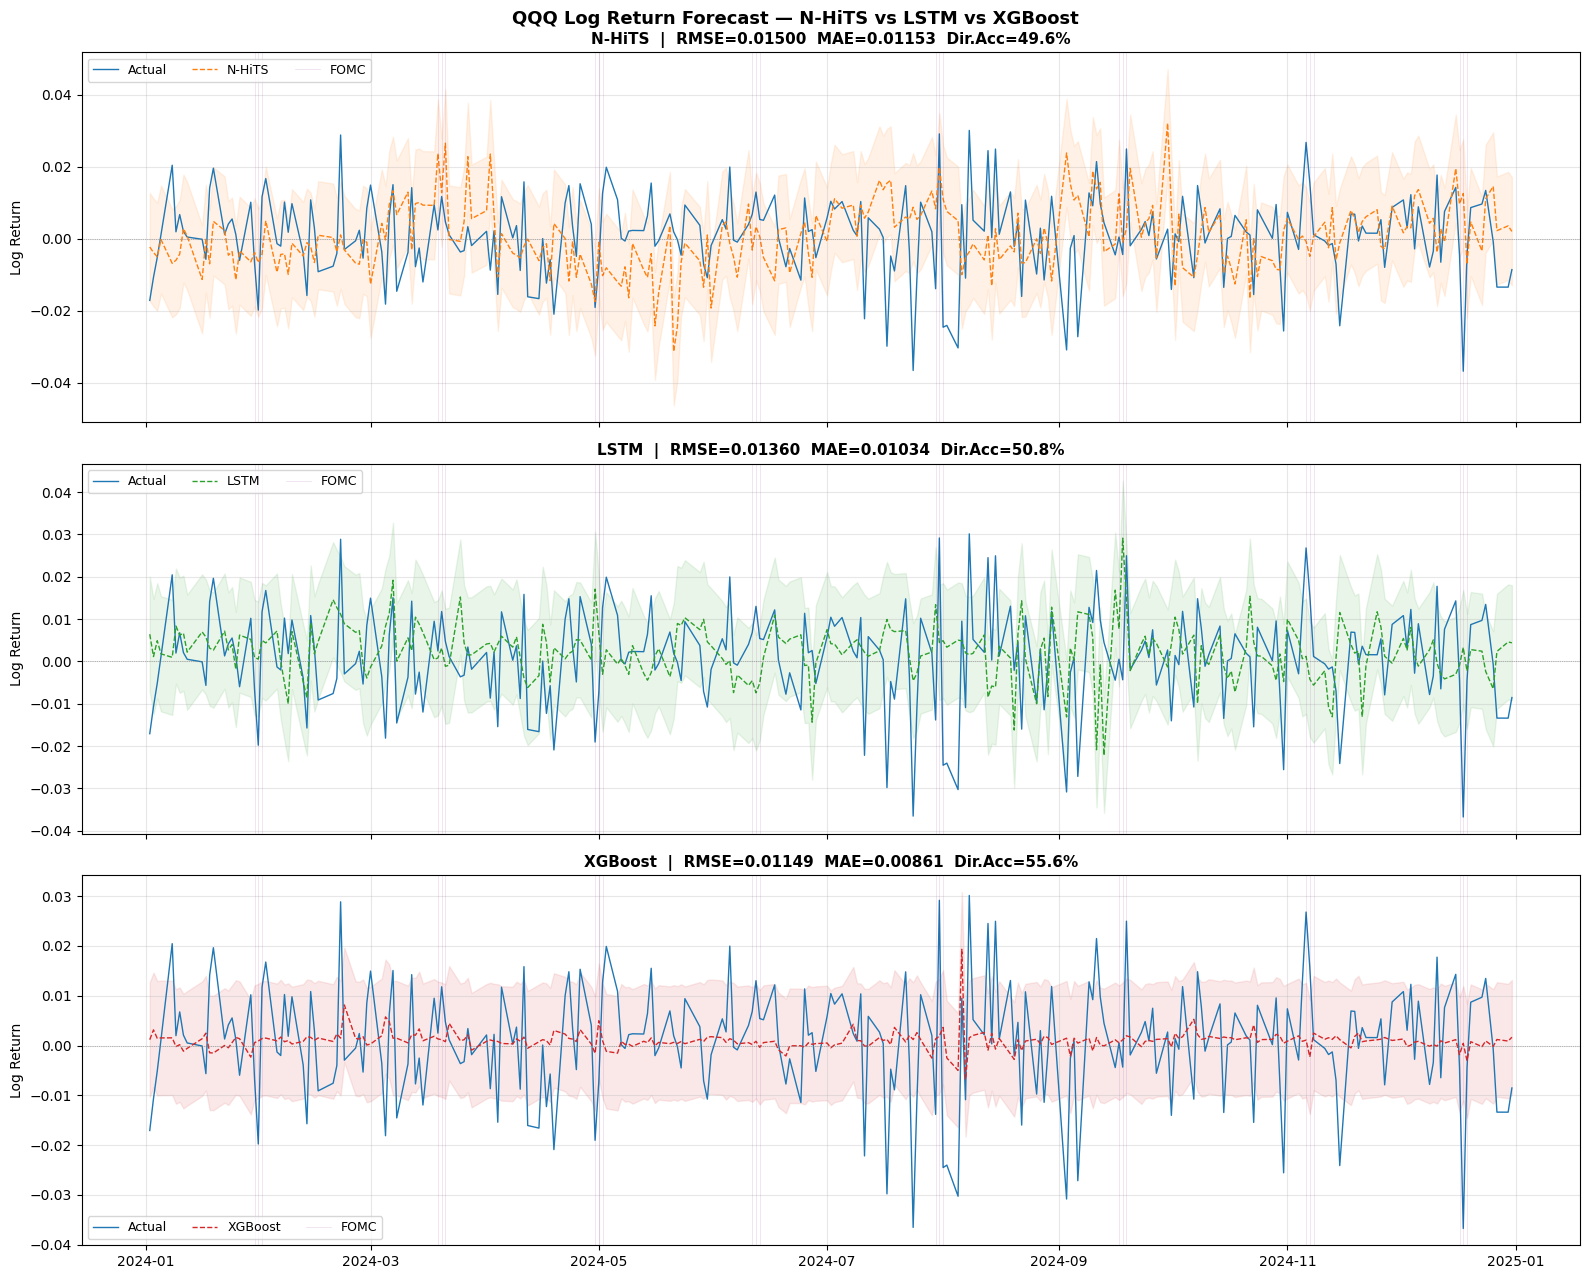

In [17]:
# ── Fig 1: Return forecast — N-HiTS vs LSTM vs XGBoost ───────────────────────
fig1, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for ax, res, col in zip(
    axes,
    [res_nhits, res_lstm,
     dict(label="XGBoost", y_true=y_test_xgb, y_pred=xgb_pred,
          rmse_ret=rmse_xgb, mae_ret=mae_xgb, dir_acc=dir_xgb)],
    ["#ff7f0e", "#2ca02c", "#d62728"]
):
    ds_axis = cv_clean["ds"] if res["label"] != "XGBoost" else xgb_ds

    ax.plot(ds_axis, res["y_true"], label="Actual",       color="#1f77b4", linewidth=1)
    ax.plot(ds_axis, res["y_pred"], label=res["label"],   color=col,       linewidth=1, linestyle="--")
    ax.fill_between(ds_axis,
                    res["y_pred"] - res["rmse_ret"],
                    res["y_pred"] + res["rmse_ret"],
                    alpha=0.1, color=col)
    for i, ed in enumerate(earn_event_days):
        ax.axvline(ed, color="green",  alpha=0.12, linewidth=0.6,
                   label="Earnings" if i == 0 else "")
    for i, fd in enumerate(fomc_event_days):
        ax.axvline(fd, color="purple", alpha=0.12, linewidth=0.6,
                   label="FOMC" if i == 0 else "")
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax.set_title(
        f"{res['label']}  |  RMSE={res['rmse_ret']:.5f}  "
        f"MAE={res['mae_ret']:.5f}  Dir.Acc={res['dir_acc']:.1f}%",
        fontweight="bold", fontsize=11
    )
    ax.set_ylabel("Log Return")
    ax.legend(fontsize=9, ncol=4)
    ax.grid(alpha=0.3)

plt.suptitle("QQQ Log Return Forecast — N-HiTS vs LSTM vs XGBoost",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_return_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

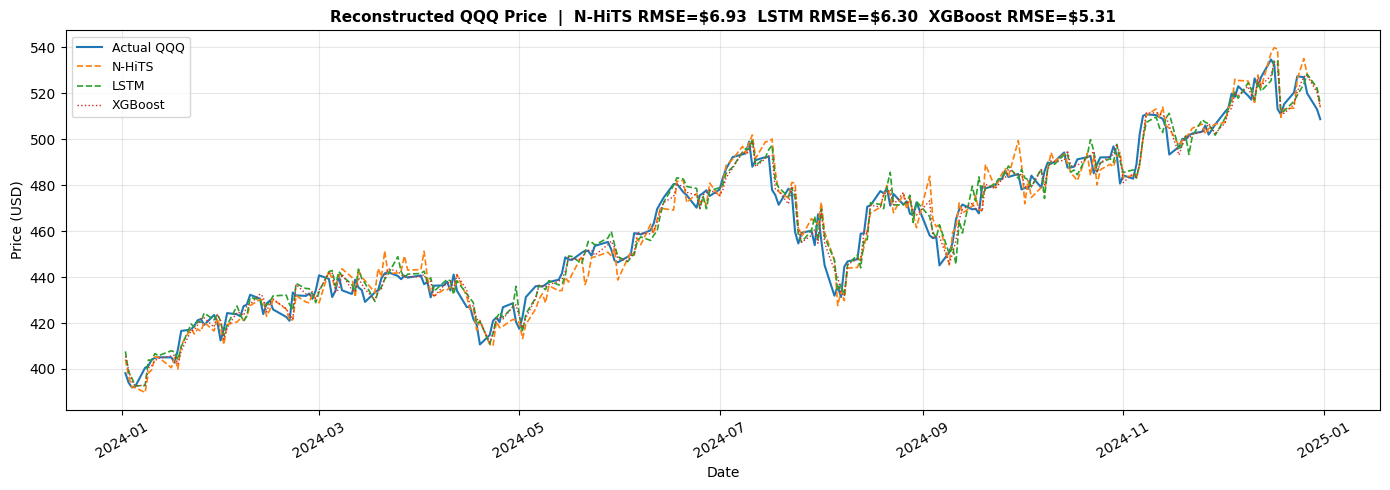

In [18]:
# ── Fig 2: Reconstructed price — all 3 models ────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 5))
ax2.plot(cv_clean["ds"], res_nhits["y_true_p"], label="Actual QQQ",
         color="#1f77b4", linewidth=1.5)
ax2.plot(cv_clean["ds"], res_nhits["y_pred_p"], label="N-HiTS",
         color="#ff7f0e", linewidth=1.2, linestyle="--")
ax2.plot(cv_clean["ds"], res_lstm["y_pred_p"],  label="LSTM",
         color="#2ca02c", linewidth=1.2, linestyle="--")
ax2.plot(xgb_ds,         xgb_pred_p,            label="XGBoost",
         color="#d62728", linewidth=1.0, linestyle=":")
ax2.set_title(
    f"Reconstructed QQQ Price  |  "
    f"N-HiTS RMSE=${res_nhits['rmse_price']:.2f}  "
    f"LSTM RMSE=${res_lstm['rmse_price']:.2f}  "
    f"XGBoost RMSE=${rmse_xgb_p:.2f}",
    fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Date"); ax2.set_ylabel("Price (USD)")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("fig2_price_reconstructed.png", dpi=150, bbox_inches="tight")
plt.show()

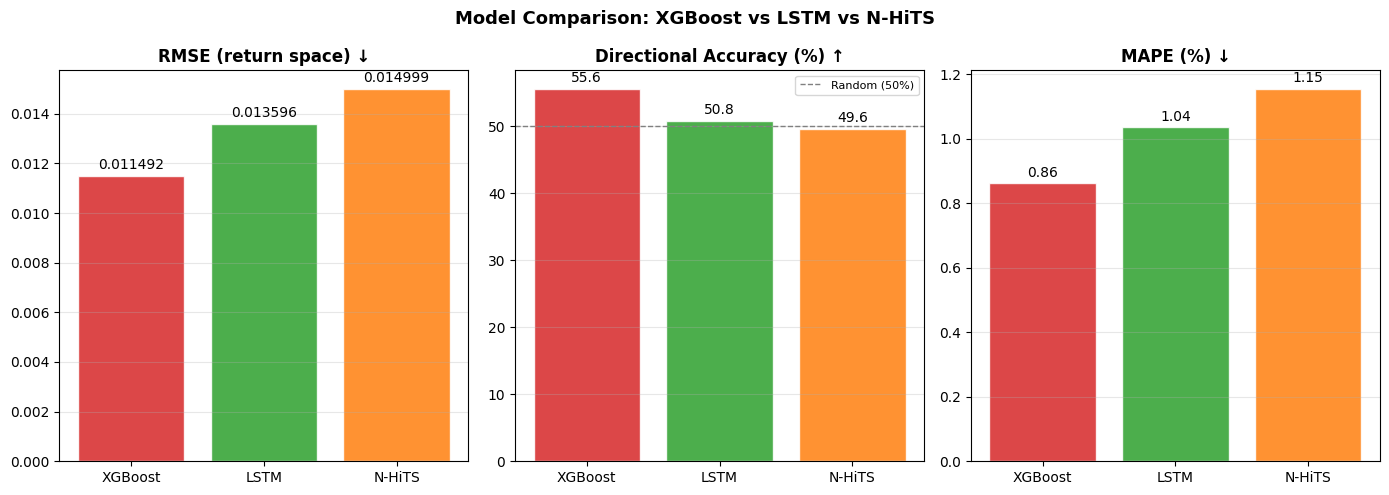

In [19]:
# ── Fig 3: Model comparison bar chart ────────────────────────────────────────
fig3, axes = plt.subplots(1, 3, figsize=(14, 5))
models     = ["XGBoost", "LSTM", "N-HiTS"]
colors     = ["#d62728", "#2ca02c", "#ff7f0e"]
rmse_vals  = [rmse_xgb,              res_lstm["rmse_ret"],  res_nhits["rmse_ret"]]
dir_vals   = [dir_xgb,               res_lstm["dir_acc"],   res_nhits["dir_acc"]]
mape_vals  = [mape_xgb,              res_lstm["mape"],      res_nhits["mape"]]
 
for ax, vals, title, fmt in zip(
    axes,
    [rmse_vals, dir_vals, mape_vals],
    ["RMSE (return space) ↓", "Directional Accuracy (%) ↑", "MAPE (%) ↓"],
    [".6f", ".1f", ".2f"]
):
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:{fmt}}", ha="center", va="bottom", fontsize=10)
    if "↑" in title:
        ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="Random (50%)")
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis="y")
 
plt.suptitle("Model Comparison: XGBoost vs LSTM vs N-HiTS", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

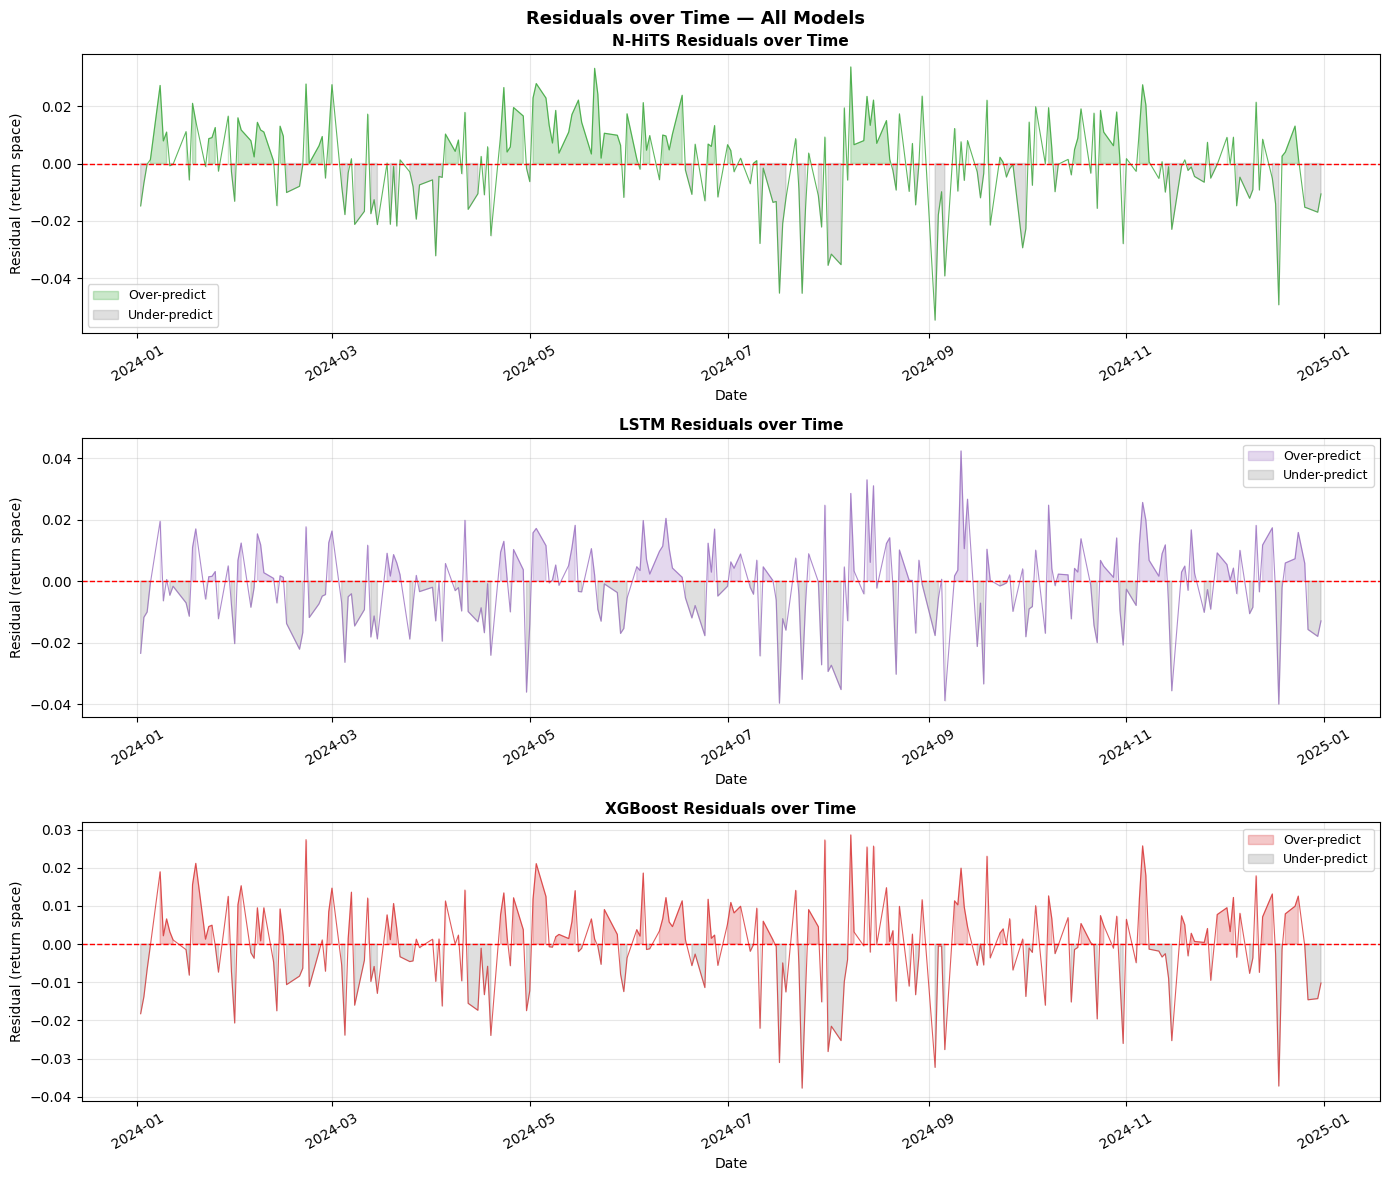

In [20]:
# ── Fig 4: Residuals — all 3 models ──────────────────────────────────────────
fig4, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

models_res = [
    ("N-HiTS",  res_nhits["residuals"], cv_clean["ds"],  "#2ca02c"),
    ("LSTM",    res_lstm["residuals"],  cv_clean["ds"],  "#9467bd"),
    ("XGBoost", xgb_residuals,          xgb_ds,          "#d62728"),
]

for ax, (label, res, ds, col) in zip(axes, models_res):
    ax.plot(ds, res, color=col, linewidth=0.8, alpha=0.75)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.fill_between(ds, res, 0, where=(res > 0), alpha=0.25,
                    color=col, label="Over-predict")
    ax.fill_between(ds, res, 0, where=(res < 0), alpha=0.25,
                    color="gray", label="Under-predict")
    for i, ed in enumerate(earn_event_days):
        ax.axvline(ed, color="green", alpha=0.15, linewidth=0.7,
                   label="Earnings window" if i == 0 else "")
    ax.set_title(f"{label} Residuals over Time", fontsize=11, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Residual (return space)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Residuals over Time — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_residuals_all.png", dpi=150, bbox_inches="tight")
plt.show()

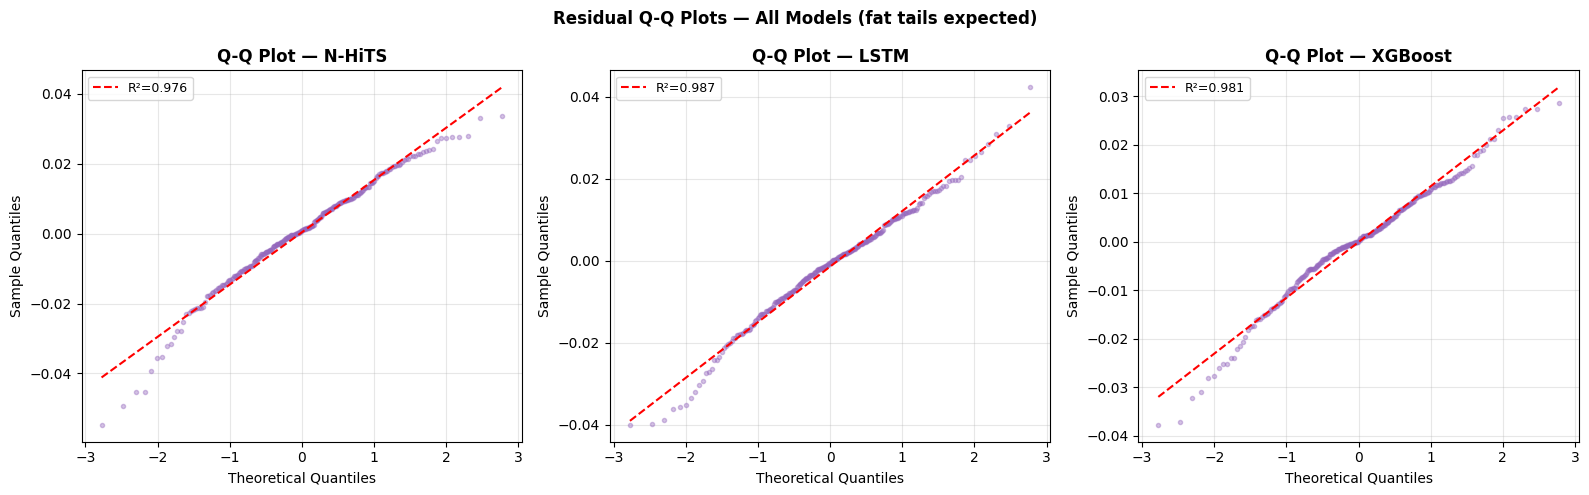

In [22]:
# ── Fig 5: Q-Q plots — all 3 models ─────────────────────────────────────────
fig5, axes = plt.subplots(1, 3, figsize=(16, 5))

models_qq = [
    ("N-HiTS",  res_nhits["residuals"]),
    ("LSTM",    res_lstm["residuals"]),
    ("XGBoost", xgb_residuals),
]

for ax, (label, res) in zip(axes, models_qq):
    (osm, osr), (slope, intercept, r) = stats.probplot(res, dist="norm")
    ax.plot(osm, osr, "o", markersize=3, alpha=0.4, color="#9467bd")
    ax.plot(osm, slope * np.array(osm) + intercept, "r--", linewidth=1.5,
            label=f"R²={r**2:.3f}")
    ax.set_title(f"Q-Q Plot — {label}", fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Residual Q-Q Plots — All Models (fat tails expected)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_qqplots.png", dpi=150, bbox_inches="tight")
plt.show()

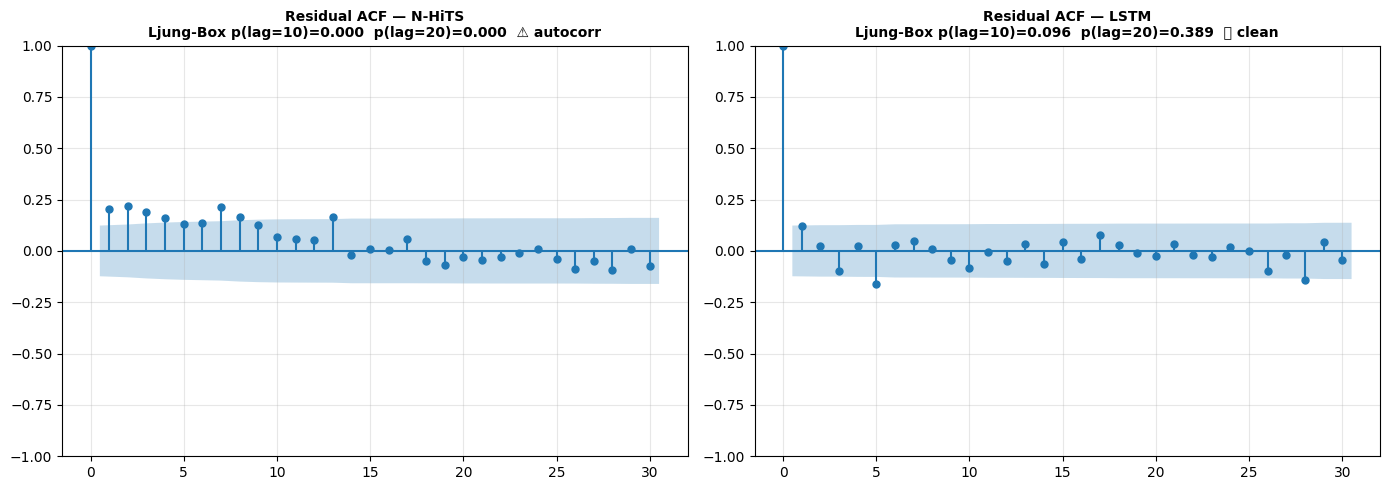

In [23]:
# ── Fig 6: ACF of residuals — N-HiTS & LSTM ─────────────────────────────────
fig6, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, label in zip(axes, [res_nhits, res_lstm], ["N-HiTS", "LSTM"]):
    plot_acf(res["residuals"], lags=30, ax=ax, color="#1f77b4", alpha=0.05)
    ax.set_title(
        f"Residual ACF — {label}\n"
        f"Ljung-Box p(lag=10)={res['lb10']:.3f}  "
        f"p(lag=20)={res['lb20']:.3f}  "
        + ("⚠️ autocorr" if res["lb10"] < 0.05 else "✅ clean"),
        fontsize=10, fontweight="bold"
    )
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig6_acf.png", dpi=150, bbox_inches="tight")
plt.show()

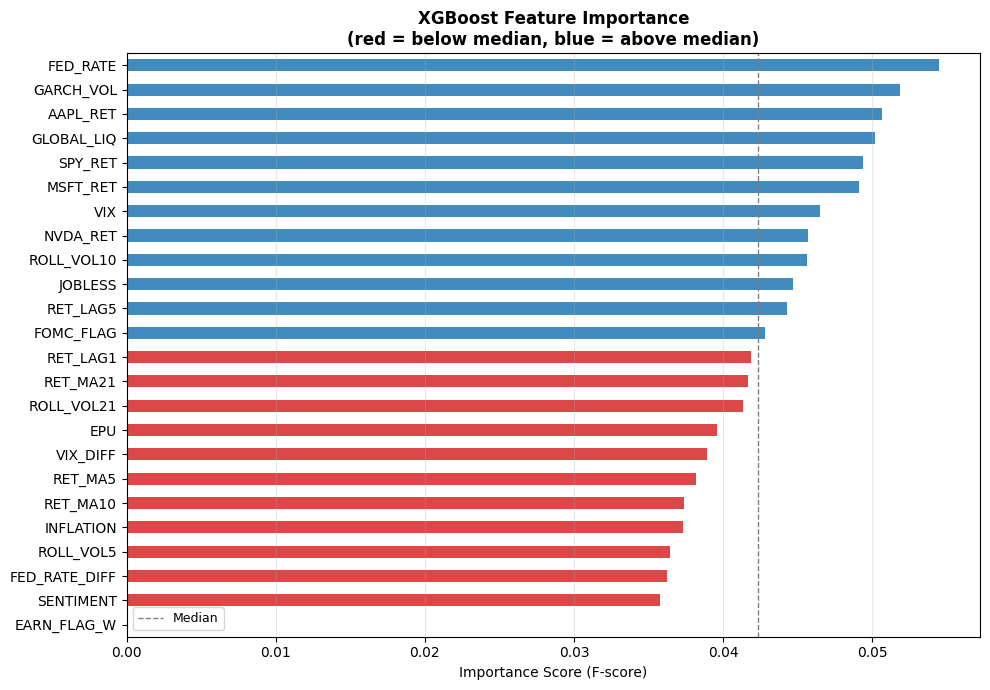

Top 5 most important features:
FED_RATE      0.054501
GARCH_VOL     0.051834
AAPL_RET      0.050666
GLOBAL_LIQ    0.050160
SPY_RET       0.049407
dtype: float32


In [24]:
fig7, ax7 = plt.subplots(figsize=(10, 7))
importances = pd.Series(
    xgb_for_importance.feature_importances_,
    index=ALL_FEATS
).sort_values(ascending=True)

colors = ["#d62728" if v < importances.median() else "#1f77b4" 
          for v in importances]

importances.plot(kind="barh", ax=ax7, color=colors, alpha=0.85)
ax7.axvline(importances.median(), color="gray", linestyle="--", 
            linewidth=1, label="Median")
ax7.set_title("XGBoost Feature Importance\n(red = below median, blue = above median)",
              fontsize=12, fontweight="bold")
ax7.set_xlabel("Importance Score (F-score)")
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("fig7_xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# 打印 top 5
print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head())

In [25]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("=" * 65)
print("FINAL SUMMARY — All Models")
print("=" * 65)
 
summary = {
    "Target variable"            : "LOG_RETURN (stationary)",
    "Horizon (H)"                : H,
    "Input size"                 : INPUT_SIZE,
    "hist_exog count"            : len(HIST_EXOG),
    "futr_exog count"            : len(FUTR_EXOG),
    "Train samples"              : len(train_df),
    "Val samples"                : len(val_df),
    "Test samples"               : len(test_df),
    "Earnings flag non-zero days": int((weighted_flag > 0).sum()),
    "FOMC flag days"             : int(fomc_flag.sum()),
}
for k, v in summary.items():
    print(f"  {k:<32} : {v}")
 
print()
print(f"  {'Model':<12} {'RMSE(ret)':>12} {'MAE(ret)':>12} {'Dir.Acc%':>10} {'RMSE($)':>10} {'MAPE%':>8}")
print(f"  {'-'*66}")
for label, rmse_r, mae_r, dir_a, rmse_p, mape_ in [
    ("XGBoost",  rmse_xgb,              mae_xgb,              dir_xgb,              rmse_xgb_p,              mape_xgb),
    ("LSTM",     res_lstm["rmse_ret"],   res_lstm["mae_ret"],   res_lstm["dir_acc"],  res_lstm["rmse_price"],  res_lstm["mape"]),
    ("N-HiTS",   res_nhits["rmse_ret"],  res_nhits["mae_ret"],  res_nhits["dir_acc"], res_nhits["rmse_price"], res_nhits["mape"]),
]:
    print(f"  {label:<12} {rmse_r:>12.6f} {mae_r:>12.6f} {dir_a:>10.2f} {rmse_p:>10.2f} {mape_:>8.2f}")

FINAL SUMMARY — All Models
  Target variable                  : LOG_RETURN (stationary)
  Horizon (H)                      : 21
  Input size                       : 63
  hist_exog count                  : 22
  futr_exog count                  : 2
  Train samples                    : 5262
  Val samples                      : 501
  Test samples                     : 252
  Earnings flag non-zero days      : 0
  FOMC flag days                   : 615

  Model           RMSE(ret)     MAE(ret)   Dir.Acc%    RMSE($)    MAPE%
  ------------------------------------------------------------------
  XGBoost          0.011492     0.008612      55.56       5.31     0.86
  LSTM             0.013596     0.010335      50.79       6.30     1.04
  N-HiTS           0.014999     0.011534      49.60       6.93     1.15


In [26]:
from neuralforecast.losses.pytorch import DistributionLoss

nhits_prob = NHITS(
    h                         = H,
    input_size                = INPUT_SIZE,
    hist_exog_list            = HIST_EXOG,
    futr_exog_list            = FUTR_EXOG,
    stack_types               = ["identity", "identity", "identity"],
    n_blocks                  = [1, 1, 1],
    mlp_units                 = [[512, 512], [512, 512], [512, 512]],
    n_pool_kernel_size        = [16, 4, 1],
    n_freq_downsample         = [12, 4, 1],
    pooling_mode              = "MaxPool1d",
    dropout_prob_theta        = 0.1,
    activation                = "ReLU",
    scaler_type               = "robust",
    learning_rate             = 1e-3,
    max_steps                 = 1000,
    val_check_steps           = 50,
    early_stop_patience_steps = 10,
    batch_size                = 32,
    random_seed               = 42,
    loss = DistributionLoss(distribution="StudentT", level=[80, 90]),
)

lstm_prob = LSTM(
    h                         = H,
    input_size                = INPUT_SIZE,
    hist_exog_list            = HIST_EXOG,
    futr_exog_list            = FUTR_EXOG,
    encoder_n_layers          = 2,
    encoder_hidden_size       = 128,
    encoder_dropout           = 0.1,
    decoder_hidden_size       = 128,
    decoder_layers            = 2,
    scaler_type               = "robust",
    learning_rate             = 1e-3,
    max_steps                 = 1000,
    val_check_steps           = 50,
    early_stop_patience_steps = 10,
    batch_size                = 32,
    random_seed               = 42,
    loss = DistributionLoss(distribution="StudentT", level=[80, 90]),
)
 
nf_prob = NeuralForecast(models=[nhits_prob, lstm_prob], freq="B")
 
print(f"  Loss function   : StudentT (NLL)")
print(f"  Output          : distributional parameters (µ, σ, ν)")
print(f"  H = {H} | Input size = {INPUT_SIZE}\n")

Seed set to 42
Seed set to 42


  Loss function   : StudentT (NLL)
  Output          : distributional parameters (µ, σ, ν)
  H = 21 | Input size = 63



In [27]:
# ── Step 2: Train ─────────────────────────────────────────────────────────────
t0_prob = time.time()
nf_prob.fit(df=trainval_df, val_size=VAL_SIZE)
train_time_prob = time.time() - t0_prob
print(f"  ✅ Training complete in {train_time_prob:.1f}s\n")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | padder_train | ConstantPad1d    | 0      | train | 0    
2 | scaler       | TemporalNorm     | 0      | train | 0    
3 | blocks       | ModuleList       | 3.6 M  | train | 0    
------------------------------------------------------------------
3.6 M     Trainable params
5         Non-trainable params
3.6 M     Total params
14.380    Total estimated model params size (MB)
43        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 549: 100%|██████████| 1/1 [00:00<00:00,  4.24it/s, v_num=33, train_loss_step=-3.81, train_loss_epoch=-3.81, valid_loss=-1.40]

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | padder_train | ConstantPad1d    | 0      | train | 0    
2 | scaler       | TemporalNorm     | 0      | train | 0    
3 | hist_encoder | LSTM             | 211 K  | train | 0    
4 | mlp_decoder  | MLP              | 17.2 K | train | 0    
------------------------------------------------------------------
228 K     Trainable params
5         Non-trainable params
228 K     Total params
0.914     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0


Epoch 549: 100%|██████████| 1/1 [00:00<00:00,  5.13it/s, v_num=34, train_loss_step=-3.95, train_loss_epoch=-3.95, valid_loss=-0.483]
  ✅ Training complete in 161.6s



In [28]:
# ── Step 3: Rolling CV ────────────────────────────────────────────────────────
cv_prob = nf_prob.cross_validation(
    df        = nf_df,
    val_size  = VAL_SIZE,
    test_size = TEST_SIZE,
    n_windows = None,
    step_size = H,
)
 
print("  CV columns:", cv_prob.columns.tolist())

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | padder_train | ConstantPad1d    | 0      | train | 0    
2 | scaler       | TemporalNorm     | 0      | train | 0    
3 | blocks       | ModuleList       | 3.6 M  | train | 0    
------------------------------------------------------------------
3.6 M     Trainable params
5         Non-trainable params
3.6 M     Total para

Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  4.66it/s, v_num=35, train_loss_step=-3.78, train_loss_epoch=-3.78, valid_loss=-1.68]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 23.23it/s]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type             | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss         | DistributionLoss | 5      | train | 0    
1 | padder_train | ConstantPad1d    | 0      | train | 0    
2 | scaler       | TemporalNorm     | 0      | train | 0    
3 | hist_encoder | LSTM             | 211 K  | train | 0    
4 | mlp_decoder  | MLP              | 17.2 K | train | 0    
------------------------------------------------------------------
228 K     Trainable params
5         Non-trainable params
228 K     Total params
0.914     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
0

Epoch 49: 100%|██████████| 1/1 [00:00<00:00,  5.25it/s, v_num=37, train_loss_step=-4.15, train_loss_epoch=-4.15, valid_loss=0.565]

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 27.17it/s]
  CV columns: ['unique_id', 'ds', 'cutoff', 'NHITS', 'NHITS-median', 'NHITS-lo-90', 'NHITS-lo-80', 'NHITS-hi-80', 'NHITS-hi-90', 'LSTM', 'LSTM-median', 'LSTM-lo-90', 'LSTM-lo-80', 'LSTM-hi-80', 'LSTM-hi-90', 'y']


In [29]:
# ── Step 4: Extract median forecasts ─────────────────────────────────────────
# With StudentT loss, neuralforecast outputs distribution parameters.
# Column names will be like "NHITS-median", "LSTM-median".
# We use the median as the point forecast for comparison with baseline.
 
nhits_col = [c for c in cv_prob.columns if "NHITS" in c and "median" in c]
lstm_col  = [c for c in cv_prob.columns if "LSTM"  in c and "median" in c]
 
# Fallback: if no "median" column, use mean
if not nhits_col:
    nhits_col = [c for c in cv_prob.columns if "NHITS" in c and c != "y"]
if not lstm_col:
    lstm_col  = [c for c in cv_prob.columns if "LSTM"  in c and c != "y"]
 
print(f"  Using NHITS col : {nhits_col[0]}")
print(f"  Using LSTM  col : {lstm_col[0]}\n")
 
cv_prob_clean = cv_prob.dropna(subset=["y", nhits_col[0], lstm_col[0]]).copy()
 

  Using NHITS col : NHITS-median
  Using LSTM  col : LSTM-median



In [30]:
# ── Step 5: Evaluate ──────────────────────────────────────────────────────────
print("  Probabilistic model results:")
print(f"  {'Model':<15} {'RMSE(ret)':>12} {'MAE(ret)':>12} {'Dir.Acc%':>10}")
print(f"  {'-'*52}")
 
for label, col in [("NHITS-StudentT", nhits_col[0]), ("LSTM-StudentT", lstm_col[0])]:
    y_true = cv_prob_clean["y"].values
    y_pred = cv_prob_clean[col].values
    rmse_  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_   = mean_absolute_error(y_true, y_pred)
    dir_   = np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
    print(f"  {label:<15} {rmse_:>12.6f} {mae_:>12.6f} {dir_:>10.2f}%")
 
print()

  Probabilistic model results:
  Model              RMSE(ret)     MAE(ret)   Dir.Acc%
  ----------------------------------------------------
  NHITS-StudentT      0.013903     0.010913      48.02%
  LSTM-StudentT       0.013083     0.010308      51.19%



In [31]:
print(f"Actual std              : {cv_prob_clean['y'].std():.6f}")
print(f"NHITS-StudentT pred std : {cv_prob_clean[nhits_col[0]].std():.6f}")
print(f"LSTM-StudentT  pred std : {cv_prob_clean[lstm_col[0]].std():.6f}")

Actual std              : 0.011361
NHITS-StudentT pred std : 0.007219
LSTM-StudentT  pred std : 0.006424


In [32]:
# ── Step 6: Compare std — check for mean reversion bias ──────────────────────
print("  Dispersion check (mean reversion bias):")
print(f"    Actual std              : {cv_prob_clean['y'].std():.6f}")
print(f"    NHITS-StudentT pred std : {cv_prob_clean[nhits_col[0]].std():.6f}")
print(f"    LSTM-StudentT  pred std : {cv_prob_clean[lstm_col[0]].std():.6f}")
print()

  Dispersion check (mean reversion bias):
    Actual std              : 0.011361
    NHITS-StudentT pred std : 0.007219
    LSTM-StudentT  pred std : 0.006424



In [33]:
# ── Step 7: Side-by-side comparison with baseline ────────────────────────────
print("  Comparison — Baseline (MAE) vs Probabilistic (StudentT):")
print(f"  {'Model':<20} {'RMSE':>10} {'Dir.Acc%':>10} {'Pred std':>12}")
print(f"  {'-'*55}")
 
for label, y_p, ds_ in [
    ("NHITS-MAE (base)",  cv_clean["NHITS"].values,        cv_clean["ds"]),
    ("LSTM-MAE  (base)",  cv_clean["LSTM"].values,         cv_clean["ds"]),
    ("NHITS-StudentT",    cv_prob_clean[nhits_col[0]].values, cv_prob_clean["ds"]),
    ("LSTM-StudentT",     cv_prob_clean[lstm_col[0]].values,  cv_prob_clean["ds"]),
]:
    y_true = cv_clean["y"].values if "base" in label else cv_prob_clean["y"].values
    rmse_  = np.sqrt(mean_squared_error(y_true, y_p))
    dir_   = np.mean(np.sign(y_true) == np.sign(y_p)) * 100
    std_   = y_p.std()
    print(f"  {label:<20} {rmse_:>10.6f} {dir_:>10.2f}% {std_:>12.6f}")
 

  Comparison — Baseline (MAE) vs Probabilistic (StudentT):
  Model                      RMSE   Dir.Acc%     Pred std
  -------------------------------------------------------
  NHITS-MAE (base)       0.014999      49.60%     0.009147
  LSTM-MAE  (base)       0.013596      50.79%     0.006367
  NHITS-StudentT         0.013903      48.02%     0.007204
  LSTM-StudentT          0.013083      51.19%     0.006411


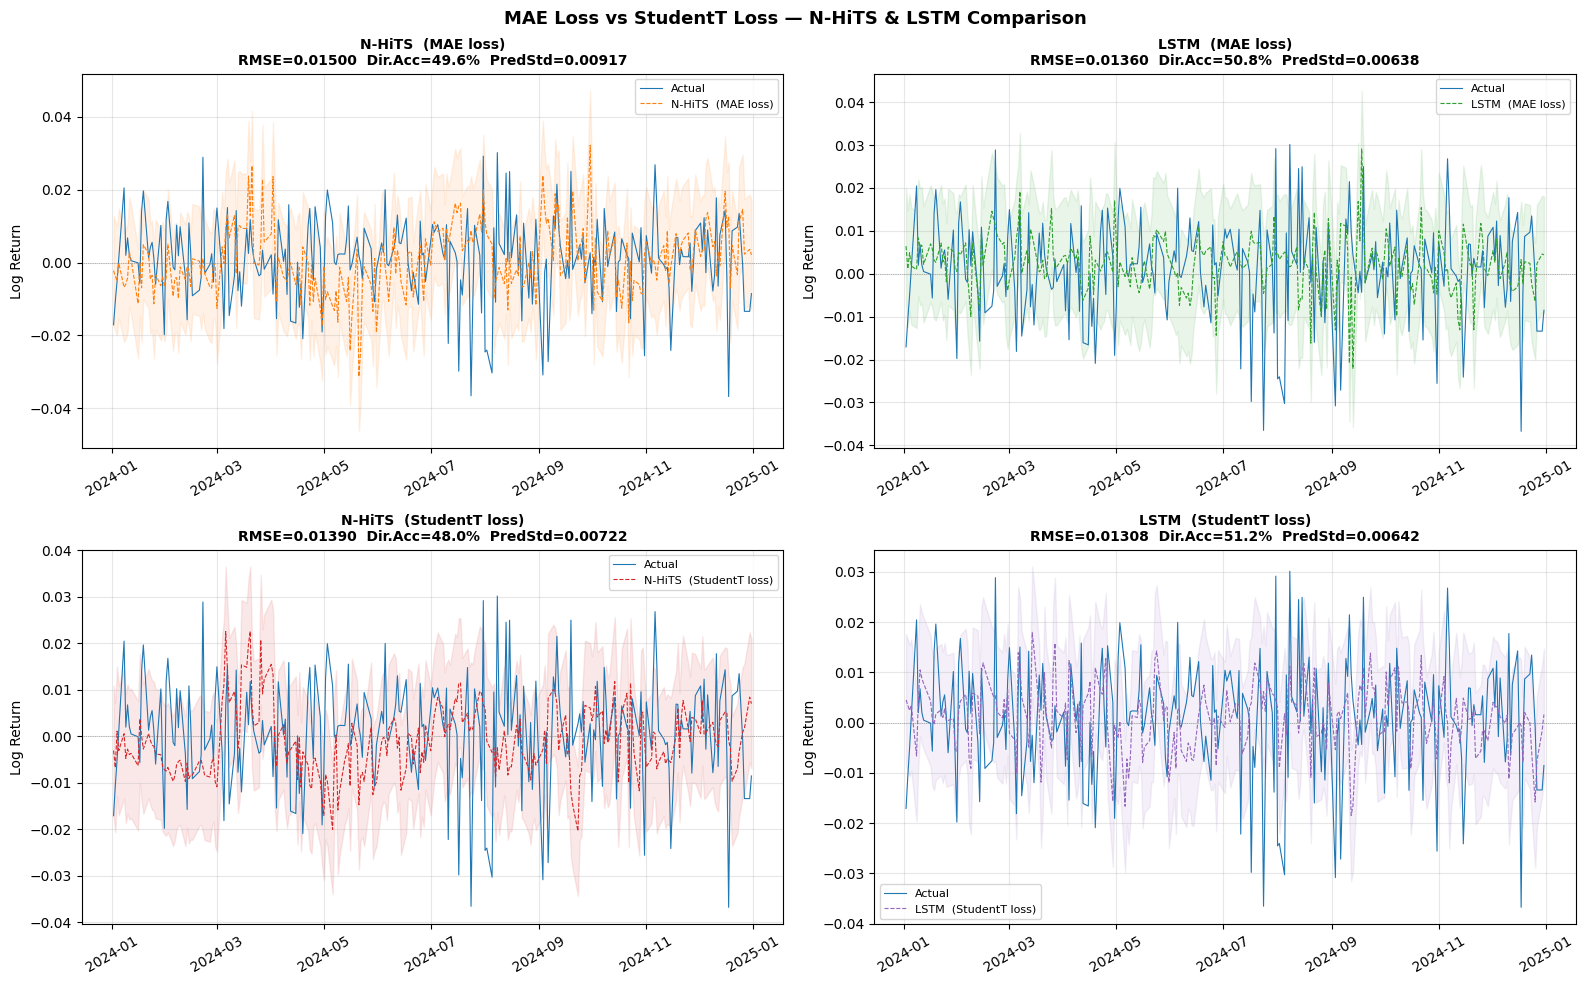

  ✅ Alternative probabilistic model complete.
  Figures saved to fig_prob_comparison.png


In [34]:
# ── Step 8: Plot comparison ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=False)
 
configs = [
    (axes[0,0], cv_clean["ds"],           cv_clean["y"],         cv_clean["NHITS"],            "N-HiTS  (MAE loss)",       "#ff7f0e"),
    (axes[0,1], cv_clean["ds"],           cv_clean["y"],         cv_clean["LSTM"],             "LSTM  (MAE loss)",          "#2ca02c"),
    (axes[1,0], cv_prob_clean["ds"],      cv_prob_clean["y"],    cv_prob_clean[nhits_col[0]],  "N-HiTS  (StudentT loss)",   "#d62728"),
    (axes[1,1], cv_prob_clean["ds"],      cv_prob_clean["y"],    cv_prob_clean[lstm_col[0]],   "LSTM  (StudentT loss)",     "#9467bd"),
]
 
for ax, ds_, y_true_, y_pred_, label, col in configs:
    rmse_ = np.sqrt(mean_squared_error(y_true_, y_pred_))
    dir_  = np.mean(np.sign(y_true_) == np.sign(y_pred_)) * 100
    ax.plot(ds_, y_true_, label="Actual",  color="#1f77b4", linewidth=0.8)
    ax.plot(ds_, y_pred_, label=label,     color=col,       linewidth=0.8, linestyle="--")
    ax.fill_between(ds_, y_pred_ - rmse_, y_pred_ + rmse_,
                    alpha=0.1, color=col)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
    ax.set_title(f"{label}\nRMSE={rmse_:.5f}  Dir.Acc={dir_:.1f}%  PredStd={y_pred_.std():.5f}",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("Log Return")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
 
plt.suptitle("MAE Loss vs StudentT Loss — N-HiTS & LSTM Comparison",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_prob_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("  ✅ Alternative probabilistic model complete.")
print("  Figures saved to fig_prob_comparison.png")

In [35]:
nhits_med  = "NHITS-median"
nhits_lo80 = "NHITS-lo-80"
nhits_hi80 = "NHITS-hi-80"
nhits_lo90 = "NHITS-lo-90"
nhits_hi90 = "NHITS-hi-90"

lstm_med   = "LSTM-median"
lstm_lo80  = "LSTM-lo-80"
lstm_hi80  = "LSTM-hi-80"
lstm_lo90  = "LSTM-lo-90"
lstm_hi90  = "LSTM-hi-90"

cv_prob_clean = cv_prob.dropna(subset=["y", nhits_med, lstm_med]).copy()
y_true = cv_prob_clean["y"].values


print("\n  ── Probabilistic Metrics (Interval Coverage) ───────────────")
print(f"  {'Model':<20} {'80% Coverage':>14} {'90% Coverage':>14} {'Avg Error':>12}")
print(f"  {'-'*63}")
 
for label, lo80, hi80, lo90, hi90 in [
    ("NHITS-StudentT", nhits_lo80, nhits_hi80, nhits_lo90, nhits_hi90),
    ("LSTM-StudentT",  lstm_lo80,  lstm_hi80,  lstm_lo90,  lstm_hi90),
]:
    if lo80 and hi80 and lo90 and hi90:
        cov80 = np.mean(
            (cv_prob_clean["y"] >= cv_prob_clean[lo80]) &
            (cv_prob_clean["y"] <= cv_prob_clean[hi80])
        ) * 100
        cov90 = np.mean(
            (cv_prob_clean["y"] >= cv_prob_clean[lo90]) &
            (cv_prob_clean["y"] <= cv_prob_clean[hi90])
        ) * 100
        avg_err = (abs(cov80 - 80) + abs(cov90 - 90)) / 2
        print(f"  {label:<20} {cov80:>13.1f}% {cov90:>13.1f}% {avg_err:>11.1f}%")
    else:
        print(f"  {label:<20} {'N/A':>14} {'N/A':>14} {'N/A':>12}")
 
print(f"\n  Ideal  : 80% coverage = 80.0%,  90% coverage = 90.0%")
print(f"  >ideal : intervals too wide  (underconfident)")
print(f"  <ideal : intervals too narrow (overconfident)")


  ── Probabilistic Metrics (Interval Coverage) ───────────────
  Model                  80% Coverage   90% Coverage    Avg Error
  ---------------------------------------------------------------
  NHITS-StudentT                35.7%          48.0%        43.1%
  LSTM-StudentT                 34.1%          41.7%        47.1%

  Ideal  : 80% coverage = 80.0%,  90% coverage = 90.0%
  >ideal : intervals too wide  (underconfident)
  <ideal : intervals too narrow (overconfident)


In [ ]:
# =============================================================================
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import math
 
print("=" * 65)
print("CUSTOM NLL — PyTorch LSTM with Skewed Student's t Loss")
print("=" * 65)
 


CUSTOM NLL — PyTorch LSTM with Skewed Student's t Loss


In [50]:
# =============================================================================
# 1. NLL Loss Functions (translated from Michańków 2025 TensorFlow code)
# =============================================================================
 
 
# Parameter bounds — calibrated for raw-scale log returns (~0.01 std)
# SIGMA_MIN: floor for σ, set to ~20% of typical daily return std
# NU_MIN:    floor for ν > 2 ensures Student's t variance exists
SIGMA_MIN = 0.002
NU_MIN    = 2.1
 
def nll_normal(y_true, y_pred):
    """
    Negative Log-Likelihood for Normal distribution.
    y_pred: [batch, 2] → [µ, raw_σ]
 
    SIGMA_MIN prevents σ collapsing to near-zero (common failure mode
    when minimizing NLL with unconstrained σ on small-scale returns).
    """
    mu    = y_pred[:, 0]
    sigma = SIGMA_MIN + torch.nn.functional.softplus(y_pred[:, 1])
 
    loss = (0.5 * torch.log(2 * torch.tensor(math.pi) * sigma**2)
            + (y_true - mu)**2 / (2 * sigma**2))
    return loss.mean()
 
 
def nll_student_t(y_true, y_pred):
    """
    Negative Log-Likelihood for Student's t distribution.
    y_pred: [batch, 3] → [µ, raw_σ, raw_ν]
    Translated from loss_st() in Michańków (2025).
 
    NU_MIN = 2.1 ensures variance exists (ν > 2 required).
    """
    mu    = y_pred[:, 0]
    sigma = SIGMA_MIN + torch.nn.functional.softplus(y_pred[:, 1])
    nu    = NU_MIN    + torch.nn.functional.softplus(y_pred[:, 2])
 
    a = torch.lgamma((nu + 1.) / 2.) - torch.lgamma(nu / 2.)
    b = 0.5 * torch.log(nu * torch.tensor(math.pi))
    c = 0.5 * torch.log(sigma**2)
    d = (nu + 1.) / 2.
    e = 1. + (y_true - mu)**2 / (nu * sigma**2)
 
    loss = -a + b + c + d * torch.log(e)
    return loss.mean()
 
 
def nll_skewed_student_t(y_true, y_pred):
    """
    Negative Log-Likelihood for Skewed Student's t distribution.
    y_pred: [batch, 4] → [µ, raw_σ, raw_ν, raw_ξ]
    Translated from loss_skew_st() in Michańków (2025).
    ξ > 1: right skew, ξ < 1: left skew, ξ = 1: symmetric
    """
    mu    = y_pred[:, 0]
    sigma = SIGMA_MIN + torch.nn.functional.softplus(y_pred[:, 1])
    nu    = NU_MIN    + torch.nn.functional.softplus(y_pred[:, 2])
    xi    = 1e-3      + torch.nn.functional.softplus(y_pred[:, 3])
 
    # Normalisation constant: 2 / (ξ + 1/ξ)
    expr1 = -torch.log(2. / (xi + 1. / xi))
 
    # Student's t kernel constant
    a = torch.exp(torch.lgamma((nu + 1.) / 2.)
                  - torch.lgamma(nu / 2.)
                  - 0.5 * torch.log(nu * torch.tensor(math.pi)))
 
    c = torch.log(sigma)
    d = (nu + 1.) / 2.
 
    # Standardised residual
    eps = (y_true - mu) / sigma
 
    # Heaviside: 1 if eps > 0, else 0
    H_pos = (eps > 0).float()
 
    # Piecewise kernel (Fernandez & Steel 1998 transformation)
    neg_kernel = torch.pow(1. + (xi * eps)**2 / nu, -d)
    pos_kernel = torch.pow(1. + eps**2 / (xi**2 * nu), -d)
 
    kernel = neg_kernel * (1. - H_pos) + pos_kernel * H_pos
 
    loss = expr1 + c - torch.log(a * kernel)
    return loss.mean()
 
 
LOSS_FN = {
    "normal"   : (nll_normal,          2),
    "student_t": (nll_student_t,        3),
    "skewed_st": (nll_skewed_student_t, 4),   # ← paper's best
}
 

In [38]:
# =============================================================================
# 2. PyTorch LSTM Model
# =============================================================================
 
class ProbLSTM(nn.Module):
    """
    LSTM that outputs parameters of a probability distribution.
    Architecture mirrors Michańków (2025): LSTM layers → Dense(n_params)
    """
    def __init__(self, n_features, hidden_size=128, n_layers=2,
                 dropout=0.0, n_params=4):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size   = n_features,
            hidden_size  = hidden_size,
            num_layers   = n_layers,
            batch_first  = True,
            dropout      = dropout if n_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, n_params)
 
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # take last time step
 

In [39]:
# =============================================================================
# 3. Data Preparation
# =============================================================================
 
SEQ_LEN    = 10          # lookback window — matches paper's sequence_length=10
DIST       = "skewed_st" # change to "normal" or "student_t" to compare
loss_fn, N_PARAMS = LOSS_FN[DIST]
 
ALL_FEATS  = HIST_EXOG + FUTR_EXOG
feat_cols  = ALL_FEATS
 
# Build numpy arrays from nf_df (already has shift(1) applied)
df_np = nf_df[["y"] + feat_cols].copy().dropna()
X_all = df_np[feat_cols].values.astype("float32")
y_all = df_np["y"].values.astype("float32")
ds_all = nf_df.loc[df_np.index, "ds"].values
 
def make_sequences(X, y, seq_len):
    """Convert flat arrays to (samples, seq_len, features) + targets."""
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return (torch.tensor(Xs, dtype=torch.float32),
            torch.tensor(ys,  dtype=torch.float32))
 
# Find test start index
val_end_date  = pd.Timestamp(VAL_END)
test_start_pos = np.searchsorted(ds_all, val_end_date) + 1
 
print(f"  Distribution    : {DIST} ({N_PARAMS} params)")
print(f"  Sequence length : {SEQ_LEN}")
print(f"  Features        : {len(feat_cols)}")
print(f"  Test start idx  : {test_start_pos} / {len(y_all)}\n")
 

  Distribution    : skewed_st (4 params)
  Sequence length : 10
  Features        : 24
  Test start idx  : 5764 / 6015



In [51]:
# =============================================================================
# 4. Rolling Expanding Window Training + Evaluation
# =============================================================================
 
HIDDEN_SIZE  = 128
N_LAYERS     = 2
LR           = 3e-3
EPOCHS       = 100        # keep low for speed; paper used 300
BATCH_SIZE   = 64
PATIENCE     = 5          # early stopping patience
REFIT_EVERY  = H          # refit every H=21 steps (same cadence as NF models)
 
preds_mu    = []
preds_sigma = []
preds_nu    = []
preds_xi    = []
true_vals   = []
pred_ds     = []
 
t_nll = time.time()
model = None
 
for i in range(test_start_pos, len(y_all)):
    # ── Refit every REFIT_EVERY steps ────────────────────────────────────────
    if (i - test_start_pos) % REFIT_EVERY == 0:
        # Training data: everything up to current position
        X_tr_raw = X_all[:i]
        y_tr_raw = y_all[:i]
 
        X_seq, y_seq = make_sequences(X_tr_raw, y_tr_raw, SEQ_LEN)
 
        # Simple train/val split (last 20% as val for early stopping)
        val_split = int(len(y_seq) * 0.8)
        X_tr, y_tr = X_seq[:val_split], y_seq[:val_split]
        X_val, y_val = X_seq[val_split:], y_seq[val_split:]
 
        train_loader = DataLoader(
            TensorDataset(X_tr, y_tr),
            batch_size=BATCH_SIZE, shuffle=False
        )
 
        model = ProbLSTM(
            n_features  = len(feat_cols),
            hidden_size = HIDDEN_SIZE,
            n_layers    = N_LAYERS,
            n_params    = N_PARAMS,
        )
        optimizer = optim.Adam(model.parameters(), lr=LR, eps=1e-7)
 
        best_val   = float("inf")
        patience_c = 0
 
        for epoch in range(EPOCHS):
            model.train()
            for Xb, yb in train_loader:
                optimizer.zero_grad()
                out  = model(Xb)
                loss = loss_fn(yb, out)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
 
            # Validation loss for early stopping
            model.eval()
            with torch.no_grad():
                val_out  = model(X_val)
                val_loss = loss_fn(y_val, val_out).item()
 
            if val_loss < best_val:
                best_val    = val_loss
                best_state  = {k: v.clone() for k, v in model.state_dict().items()}
                patience_c  = 0
            else:
                patience_c += 1
                if patience_c >= PATIENCE:
                    break
 
        model.load_state_dict(best_state)
        refit_step = (i - test_start_pos) // REFIT_EVERY + 1
        total_refits = (len(y_all) - test_start_pos) // REFIT_EVERY + 1
        print(f"  Refit {refit_step}/{total_refits} at idx={i}  "
              f"best_val={best_val:.6f}  epochs={epoch+1}")
 
    # ── Predict current test point ────────────────────────────────────────────
    if i >= SEQ_LEN and model is not None:
        model.eval()
        with torch.no_grad():
            x_in = torch.tensor(
                X_all[i-SEQ_LEN:i][np.newaxis], dtype=torch.float32
            )
            out = model(x_in)[0]
 
        mu_    = out[0].item()
        sigma_ = (SIGMA_MIN + torch.nn.functional.softplus(out[1])).item()
        nu_    = (NU_MIN    + torch.nn.functional.softplus(out[2])).item() if N_PARAMS >= 3 else None
        xi_    = (1e-3      + torch.nn.functional.softplus(out[3])).item() if N_PARAMS >= 4 else None
 
        preds_mu.append(mu_)
        preds_sigma.append(sigma_)
        preds_nu.append(nu_)
        preds_xi.append(xi_)
        true_vals.append(y_all[i])
        pred_ds.append(ds_all[i])
 
nll_time = time.time() - t_nll
print(f"\n  ✅ Done in {nll_time:.1f}s\n")

  Refit 1/12 at idx=5764  best_val=-1.829227  epochs=100
  Refit 2/12 at idx=5785  best_val=-2.239797  epochs=100
  Refit 3/12 at idx=5806  best_val=-1.796538  epochs=50
  Refit 4/12 at idx=5827  best_val=-2.270629  epochs=100
  Refit 5/12 at idx=5848  best_val=-1.638726  epochs=42
  Refit 6/12 at idx=5869  best_val=-2.263208  epochs=100
  Refit 7/12 at idx=5890  best_val=-2.024896  epochs=100
  Refit 8/12 at idx=5911  best_val=-1.581257  epochs=75
  Refit 9/12 at idx=5932  best_val=-1.615203  epochs=59
  Refit 10/12 at idx=5953  best_val=-1.989922  epochs=100
  Refit 11/12 at idx=5974  best_val=-1.454224  epochs=48
  Refit 12/12 at idx=5995  best_val=-2.275842  epochs=100

  ✅ Done in 1007.0s



In [52]:
# =============================================================================
# 5. Evaluation — Point Metrics
# =============================================================================
 
preds_mu  = np.array(preds_mu)
true_vals = np.array(true_vals)
pred_ds   = pd.Series(pred_ds)
 
rmse_nll = np.sqrt(mean_squared_error(true_vals, preds_mu))
mae_nll  = mean_absolute_error(true_vals, preds_mu)
dir_nll  = np.mean(np.sign(true_vals) == np.sign(preds_mu)) * 100
 
print("  ── Point Metrics (µ as point forecast) ─────────────────")
print(f"  {'Model':<25} {'RMSE':>10} {'MAE':>10} {'Dir.Acc%':>10} {'PredStd':>10}")
print(f"  {'-'*68}")
print(f"  {'Custom LSTM-'+DIST:<25} {rmse_nll:>10.6f} {mae_nll:>10.6f} "
      f"{dir_nll:>10.2f}% {preds_mu.std():>10.6f}")
print(f"\n  Actual return std : {true_vals.std():.6f}")

  ── Point Metrics (µ as point forecast) ─────────────────
  Model                           RMSE        MAE   Dir.Acc%    PredStd
  --------------------------------------------------------------------
  Custom LSTM-skewed_st       0.024131   0.020491      53.78%   0.018951

  Actual return std : 0.011304


In [53]:
# =============================================================================
# 6. Evaluation — Interval Coverage
# =============================================================================
# For Student's t and Skewed Student's t, compute prediction intervals
# using the predicted distribution parameters.
 
from scipy.stats import t as scipy_t
 
print("\n  ── Probabilistic Metrics (Interval Coverage) ───────────")
 
if DIST in ["student_t", "skewed_st"] and preds_nu[0] is not None:
    preds_nu_arr = np.array(preds_nu)
    preds_sigma_arr = np.array(preds_sigma)
 
    # For each day, compute the 80% and 90% prediction intervals
    # using the Student's t quantiles with predicted nu
    lo80_list, hi80_list = [], []
    lo90_list, hi90_list = [], []
 
    for mu_, sigma_, nu_ in zip(preds_mu, preds_sigma_arr, preds_nu_arr):
        # Clip nu to reasonable range
        nu_clip = max(2.1, min(nu_, 100))
        lo80_list.append(mu_ + sigma_ * scipy_t.ppf(0.10, df=nu_clip))
        hi80_list.append(mu_ + sigma_ * scipy_t.ppf(0.90, df=nu_clip))
        lo90_list.append(mu_ + sigma_ * scipy_t.ppf(0.05, df=nu_clip))
        hi90_list.append(mu_ + sigma_ * scipy_t.ppf(0.95, df=nu_clip))
 
    lo80 = np.array(lo80_list)
    hi80 = np.array(hi80_list)
    lo90 = np.array(lo90_list)
    hi90 = np.array(hi90_list)
 
    cov80 = np.mean((true_vals >= lo80) & (true_vals <= hi80)) * 100
    cov90 = np.mean((true_vals >= lo90) & (true_vals <= hi90)) * 100
    avg_err = (abs(cov80 - 80) + abs(cov90 - 90)) / 2
 
    print(f"  {'Model':<25} {'80% Coverage':>14} {'90% Coverage':>14} {'Avg Error':>12}")
    print(f"  {'-'*68}")
    print(f"  {'Custom LSTM-'+DIST:<25} {cov80:>13.1f}% {cov90:>13.1f}% {avg_err:>11.1f}%")
    print(f"\n  Ideal: 80% → 80.0%,  90% → 90.0%")
    print(f"  Interval width (80%): mean={np.mean(hi80-lo80):.6f}  "
          f"actual std={true_vals.std():.6f}")
 


  ── Probabilistic Metrics (Interval Coverage) ───────────
  Model                       80% Coverage   90% Coverage    Avg Error
  --------------------------------------------------------------------
  Custom LSTM-skewed_st               3.6%           5.2%        80.6%

  Ideal: 80% → 80.0%,  90% → 90.0%
  Interval width (80%): mean=0.005160  actual std=0.011304


In [54]:
print(f"Predicted σ mean : {np.mean(preds_sigma):.6f}")
print(f"Predicted σ std  : {np.std(preds_sigma):.6f}")
print(f"Predicted ν mean : {np.mean([x for x in preds_nu if x]):.4f}")
print(f"Actual return std: {true_vals.std():.6f}")

Predicted σ mean : 0.002000
Predicted σ std  : 0.000000
Predicted ν mean : 297.7443
Actual return std: 0.011304


In [55]:
# =============================================================================
# 7. Full Comparison Table
# =============================================================================
 
print("\n  ── Full Model Comparison ────────────────────────────────")
print(f"  {'Model':<25} {'RMSE':>10} {'Dir.Acc%':>10} {'PredStd':>10}")
print(f"  {'-'*58}")
 
comparison_models = [
    ("XGBoost (fixed)",        xgb_pred,              y_test_xgb),
    ("NHITS-MAE",              cv_clean["NHITS"].values, cv_clean["y"].values),
    ("LSTM-MAE",               cv_clean["LSTM"].values,  cv_clean["y"].values),
    ("Custom LSTM-"+DIST,      preds_mu,              true_vals),
]
 
for label, yp, yt in comparison_models:
    rmse_ = np.sqrt(mean_squared_error(yt, yp))
    dir_  = np.mean(np.sign(yt) == np.sign(yp)) * 100
    std_  = yp.std()
    print(f"  {label:<25} {rmse_:>10.6f} {dir_:>10.2f}% {std_:>10.6f}")


  ── Full Model Comparison ────────────────────────────────
  Model                           RMSE   Dir.Acc%    PredStd
  ----------------------------------------------------------
  XGBoost (fixed)             0.011492      55.56%   0.001885
  NHITS-MAE                   0.014999      49.60%   0.009147
  LSTM-MAE                    0.013596      50.79%   0.006367
  Custom LSTM-skewed_st       0.024131      53.78%   0.018951


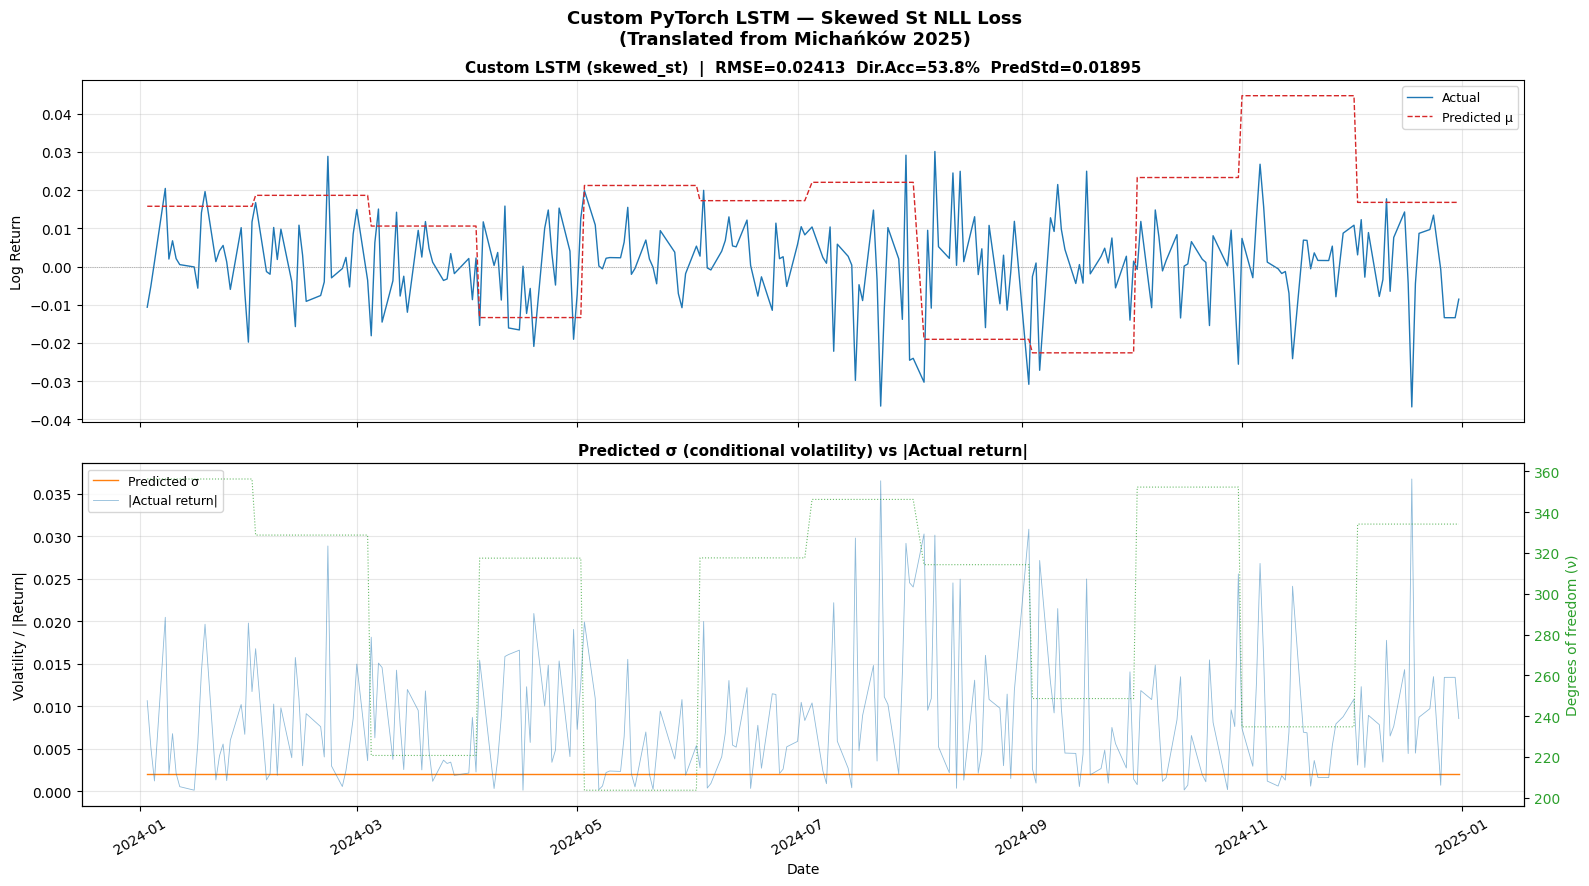


  ✅ Custom NLL model complete.
  fig_custom_nll.png saved.


In [56]:
# =============================================================================
# 8. Plot
# =============================================================================
 
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
 
# Top: predicted µ vs actual
ax = axes[0]
ax.plot(pred_ds, true_vals, label="Actual",          color="#1f77b4", linewidth=1)
ax.plot(pred_ds, preds_mu,  label="Predicted µ",     color="#d62728", linewidth=1, linestyle="--")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_title(
    f"Custom LSTM ({DIST})  |  RMSE={rmse_nll:.5f}  Dir.Acc={dir_nll:.1f}%  "
    f"PredStd={preds_mu.std():.5f}",
    fontweight="bold", fontsize=11
)
ax.set_ylabel("Log Return")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
 
# Bottom: predicted σ (conditional volatility)
ax = axes[1]
ax.plot(pred_ds, np.array(preds_sigma), color="#ff7f0e", linewidth=1, label="Predicted σ")
ax.plot(pred_ds, np.abs(true_vals),      color="#1f77b4", linewidth=0.6,
        alpha=0.5, label="|Actual return|")
if DIST in ["student_t", "skewed_st"]:
    ax2 = ax.twinx()
    ax2.plot(pred_ds, np.array(preds_nu), color="#2ca02c", linewidth=0.8,
             linestyle=":", label="Predicted ν (df)", alpha=0.7)
    ax2.set_ylabel("Degrees of freedom (ν)", color="#2ca02c")
    ax2.tick_params(axis="y", labelcolor="#2ca02c")
ax.set_title("Predicted σ (conditional volatility) vs |Actual return|",
             fontweight="bold", fontsize=11)
ax.set_xlabel("Date")
ax.set_ylabel("Volatility / |Return|")
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="x", rotation=30)
 
plt.suptitle(
    f"Custom PyTorch LSTM — {DIST.replace('_', ' ').title()} NLL Loss\n"
    f"(Translated from Michańków 2025)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("fig_custom_nll.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n  ✅ Custom NLL model complete.")
print("  fig_custom_nll.png saved.")

In [57]:
pip install nbconvert

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\jiang\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
